# HW 2 – EMG Analysis
**EE374N / 385J – Neural Engineering**

This notebook covers the EMG signal analysis homework using surface EMG data recorded from four electrodes on the forearm during three hand/wrist movements.

## Setup & Imports

In [32]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

## Load Data

In [33]:
def load_subject(path):
    """Load a subject .mat file and return a list of run dicts.
    
    Each run dict has:
        emg    : (n_samples, 4) float array
        fs     : scalar int – sampling rate (Hz)
        labels : list of 4 channel-label strings
        typ    : (n_events,) int array – event type codes
        pos    : (n_events,) int array – event sample positions
    """
    mat = scipy.io.loadmat(path, squeeze_me=False)
    run_data = mat['subject']['run'][0, 0]   # shape (1, n_runs)
    n_runs = run_data.shape[1]

    runs = []
    for i in range(n_runs):
        r = run_data[0, i]
        hdr = r['header'][0, 0]

        fs = int(hdr['fs'][0, 0])
        labels = [str(lbl[0]) for lbl in hdr['Label'][0]]

        event_tuple = hdr['EVENT'].item()   # (TYP_array, POS_array)
        typ = event_tuple[0].flatten().astype(int)
        pos = event_tuple[1].flatten().astype(int)

        runs.append(dict(
            emg=r['emg'],
            fs=fs,
            labels=labels,
            typ=typ,
            pos=pos,
        ))
    return runs


runs_s1 = load_subject('subject1.mat')
runs_s2 = load_subject('subject2.mat')

print(f"Subject 1: {len(runs_s1)} runs")
print(f"Subject 2: {len(runs_s2)} runs")

# Inspect the first run
run = runs_s1[0]
print(f"\nRun 1 – EMG shape : {run['emg'].shape}")
print(f"Run 1 – Fs        : {run['fs']} Hz")
print(f"Run 1 – Channels  : {run['labels']}")
print(f"Run 1 – Duration  : {run['emg'].shape[0] / run['fs']:.1f} s")
print(f"\nUnique event types: {np.unique(run['typ'])}")

Subject 1: 6 runs
Subject 2: 6 runs

Run 1 – EMG shape : (127488, 4)
Run 1 – Fs        : 512 Hz
Run 1 – Channels  : ['ExtProx', 'ExtDist', 'FlxProx', 'FlxDist']
Run 1 – Duration  : 249.0 s

Unique event types: [  100   101   102   200   201   202   300   301   302   768  1000 32766]


### Event code key (from PDF Table 1 / Fig. 3)

| Code | Trigger | Description |
|------|---------|-------------|
| 32766 | Run Start/End | Marks start and end of a run |
| 1000 | Trial Start | Start of inter-trial rest period (1–1.5 s) |
| 768 | Fixation | Fixation cue presented for 1 s |
| **100 / 200 / 300** | **Task Cue** | Cue for **Pinch / Point / Grasp** presented for 2 s |
| 101 / 201 / 301 | Task Start | Task execution begins |
| 102 / 202 / 302 | Task End | Task execution ends (~2.5 s after start) |

For 2.1.1 the **Task Cue** events (100/200/300) are used as trigger markers.

## 2.1.1 – First Trial of Run 1, Subject 1: Raw EMG + Trigger Labels

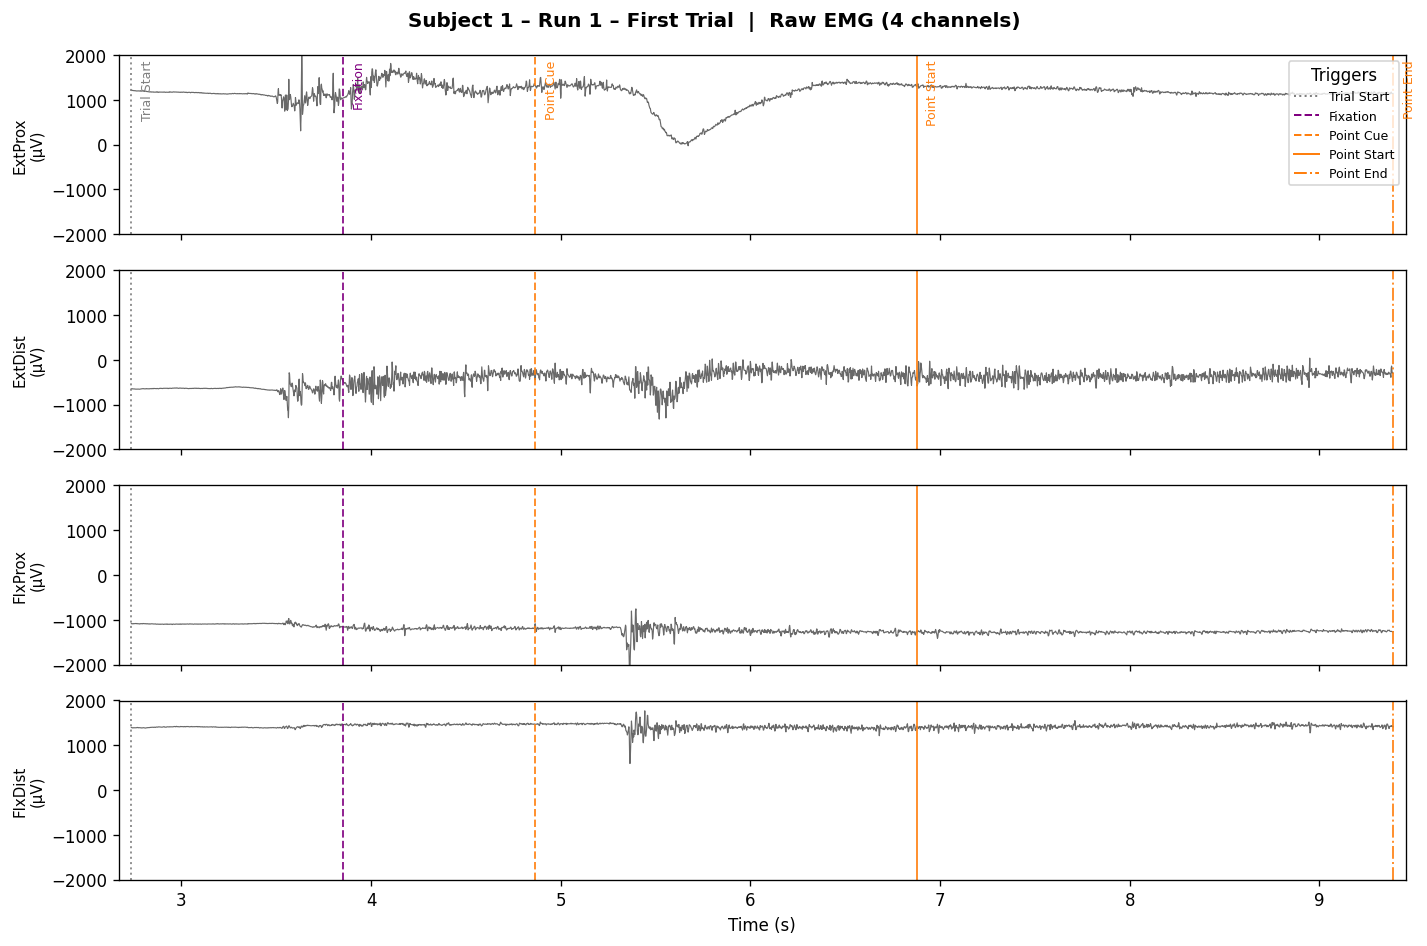

Movement performed in the first trial: Point (Task Cue code = 200)


In [34]:
run    = runs_s1[0]           # subject 1, run 1
emg    = run['emg']
fs     = run['fs']
labels = run['labels']
typ    = run['typ']
pos    = run['pos']
t      = np.arange(emg.shape[0]) / fs

# ── isolate the first trial ────────────────────────────────────────────────────
# A trial runs from its Trial Start (1000) to its Task End (102/202/302).
# The very first 1000 after the run-start (32766) begins the first trial.
trial_starts = pos[typ == 1000]
task_ends    = pos[(typ == 102) | (typ == 202) | (typ == 302)]

t0 = trial_starts[0]   # first Trial Start sample
t1 = task_ends[0]      # first Task End sample

# Slice EMG and events to the first trial window
emg_trial = emg[t0:t1+1, :]
t_trial   = (np.arange(emg_trial.shape[0]) + t0) / fs   # absolute time (s)

# All events that fall within the first trial
mask_ev  = (pos >= t0) & (pos <= t1)
ev_typ   = typ[mask_ev]
ev_pos   = pos[mask_ev]

# Trigger display config
TRIGGER_INFO = {
    1000: ('Trial Start',  'gray',        ':'),
    768:  ('Fixation',     'purple',      '--'),
    100:  ('Pinch Cue',    'tab:blue',    '--'),
    200:  ('Point Cue',    'tab:orange',  '--'),
    300:  ('Grasp Cue',    'tab:green',   '--'),
    101:  ('Pinch Start',  'tab:blue',    '-'),
    201:  ('Point Start',  'tab:orange',  '-'),
    301:  ('Grasp Start',  'tab:green',   '-'),
    102:  ('Pinch End',    'tab:blue',    '-.'),
    202:  ('Point End',    'tab:orange',  '-.'),
    302:  ('Grasp End',    'tab:green',   '-.'),
}

# ── plot ───────────────────────────────────────────────────────────────────────
n_ch = emg_trial.shape[1]
fig, axes = plt.subplots(n_ch, 1, figsize=(12, 8), sharex=True)
fig.suptitle('Subject 1 – Run 1 – First Trial  |  Raw EMG (4 channels)', fontsize=12, fontweight='bold')

# Collect legend handles (one per unique trigger in this trial)
legend_handles = {}

for ch_idx, (ax, ch_label) in enumerate(zip(axes, labels)):
    ax.plot(t_trial, emg_trial[:, ch_idx], linewidth=0.7, color='dimgray')
    ax.set_ylabel(f'{ch_label}\n(µV)', fontsize=9)
    ax.set_ylim(-2000, 2000)
    ax.margins(x=0.01)

    for code, samp in zip(ev_typ, ev_pos):
        if code not in TRIGGER_INFO:
            continue
        label_str, colour, ls = TRIGGER_INFO[code]
        t_ev = samp / fs
        line = ax.axvline(x=t_ev, color=colour, linestyle=ls, linewidth=1.2, alpha=0.85)

        # Annotate on the top subplot only
        if ch_idx == 0:
            ymin, ymax = ax.get_ylim()
            ax.text(t_ev + 0.05, ymax * 0.95, label_str,
                    color=colour, fontsize=7.5, rotation=90, va='top', ha='left')
            if label_str not in legend_handles:
                legend_handles[label_str] = plt.Line2D([], [], color=colour, linestyle=ls,
                                                        linewidth=1.2, label=label_str)

axes[-1].set_xlabel('Time (s)', fontsize=10)
axes[0].legend(handles=list(legend_handles.values()), fontsize=7.5,
               loc='upper right', framealpha=0.8, title='Triggers')

plt.tight_layout()
plt.savefig('2_1_1_first_trial.png', bbox_inches='tight')
plt.show()

# Identify the movement class
task_cue_in_trial = ev_typ[(ev_typ == 100) | (ev_typ == 200) | (ev_typ == 300)]
class_map = {100: 'Pinch', 200: 'Point', 300: 'Grasp'}
movement = class_map.get(int(task_cue_in_trial[0]), 'Unknown') if len(task_cue_in_trial) else 'Unknown'
print(f"Movement performed in the first trial: {movement} (Task Cue code = {int(task_cue_in_trial[0])})")

## PSD: Rest vs Task – Distal Flexor (First Trial, Run 1, Subject 1)

- **Rest period**: Fixation → Task Cue (768 → 100/200/300)
- **Task period**: Task Start → Task End (101/201/301 → 102/202/302)

Rest segment: samples 1971–2491  (1.02 s, 520 pts)
Task segment: samples 3521–4807  (2.51 s, 1286 pts)


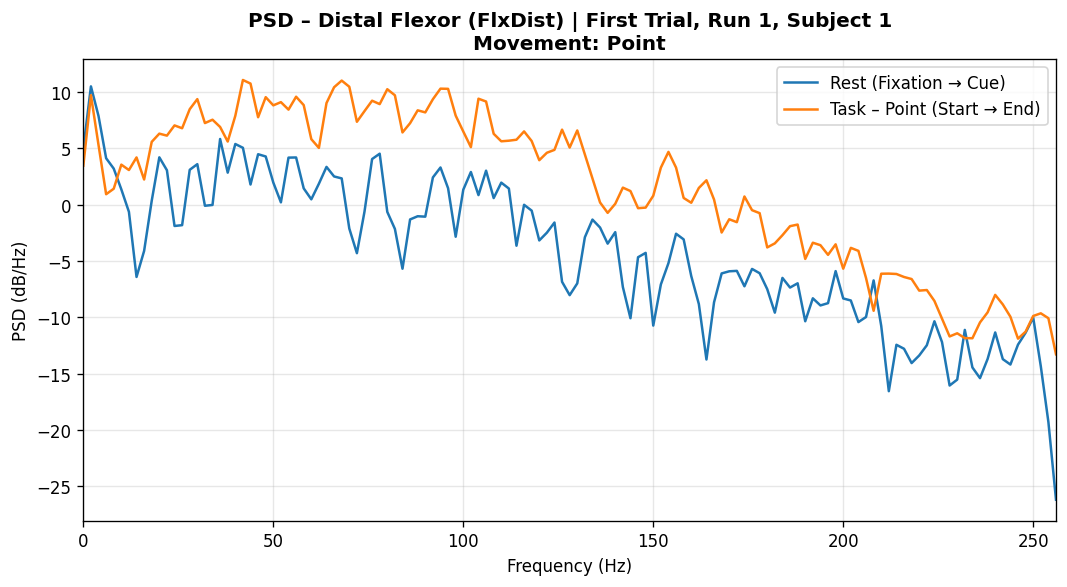

In [35]:
from scipy.signal import welch

# ── Channel index for Distal Flexor ───────────────────────────────────────────
ch_flxdist = labels.index('FlxDist')   # should be 3

# ── Identify rest and task sample boundaries from the first trial events ──────
# Rest  = Fixation (768) → Task Cue (100/200/300)
# Task  = Task Start (101/201/301) → Task End (102/202/302)

fix_idx   = np.where(ev_typ == 768)[0][0]
cue_idx   = np.where((ev_typ == 100) | (ev_typ == 200) | (ev_typ == 300))[0][0]
start_idx = np.where((ev_typ == 101) | (ev_typ == 201) | (ev_typ == 301))[0][0]
end_idx   = np.where((ev_typ == 102) | (ev_typ == 202) | (ev_typ == 302))[0][0]

rest_start = ev_pos[fix_idx]
rest_end   = ev_pos[cue_idx]
task_start = ev_pos[start_idx]
task_end   = ev_pos[end_idx]

emg_rest = emg[rest_start:rest_end, ch_flxdist]
emg_task = emg[task_start:task_end, ch_flxdist]

print(f"Rest segment: samples {rest_start}–{rest_end}  "
      f"({len(emg_rest)/fs:.2f} s, {len(emg_rest)} pts)")
print(f"Task segment: samples {task_start}–{task_end}  "
      f"({len(emg_task)/fs:.2f} s, {len(emg_task)} pts)")

# ── Compute PSDs (Welch's method) ─────────────────────────────────────────────
nperseg = min(256, len(emg_rest), len(emg_task))   # keep segments short enough
f_rest, psd_rest = welch(emg_rest, fs=fs, nperseg=nperseg)
f_task, psd_task = welch(emg_task, fs=fs, nperseg=nperseg)

# Convert to dB/Hz:  10 * log10(PSD)
psd_rest_db = 10 * np.log10(psd_rest)
psd_task_db = 10 * np.log10(psd_task)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(f_rest, psd_rest_db, label='Rest (Fixation → Cue)', linewidth=1.5)
ax.plot(f_task, psd_task_db, label=f'Task – {movement} (Start → End)', linewidth=1.5)

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (dB/Hz)')
ax.set_title(f'PSD – Distal Flexor (FlxDist) | First Trial, Run 1, Subject 1\n'
             f'Movement: {movement}', fontweight='bold')
ax.legend()
ax.set_xlim(0, fs / 2)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('psd_rest_vs_task_flxdist.png', bbox_inches='tight')
plt.show()

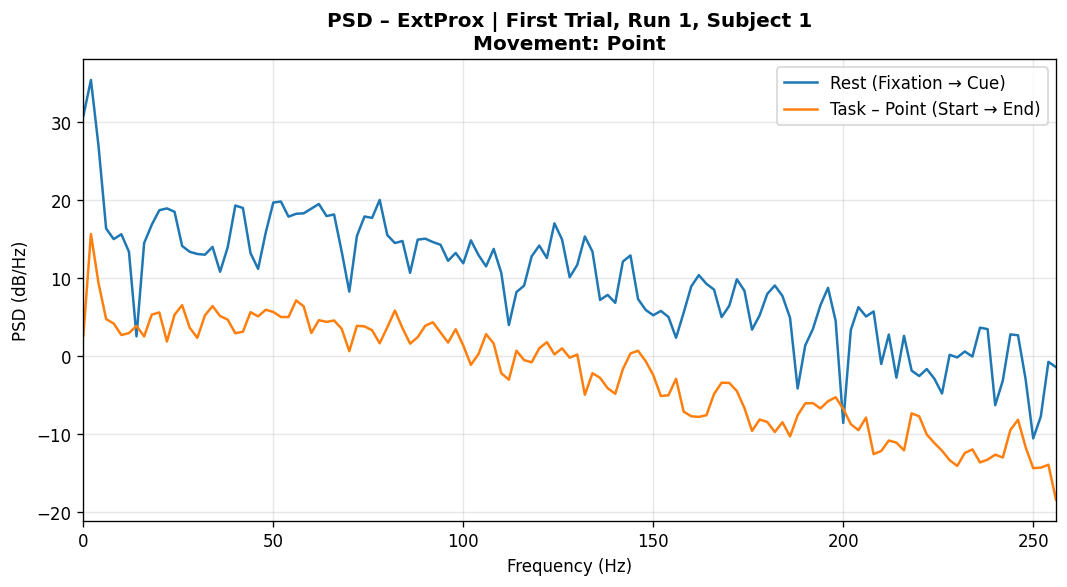

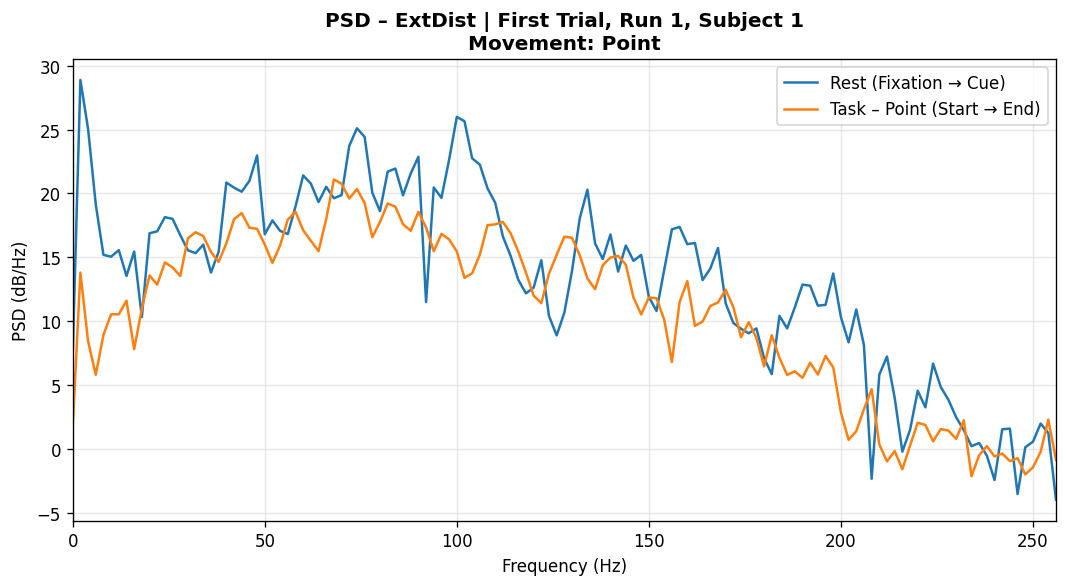

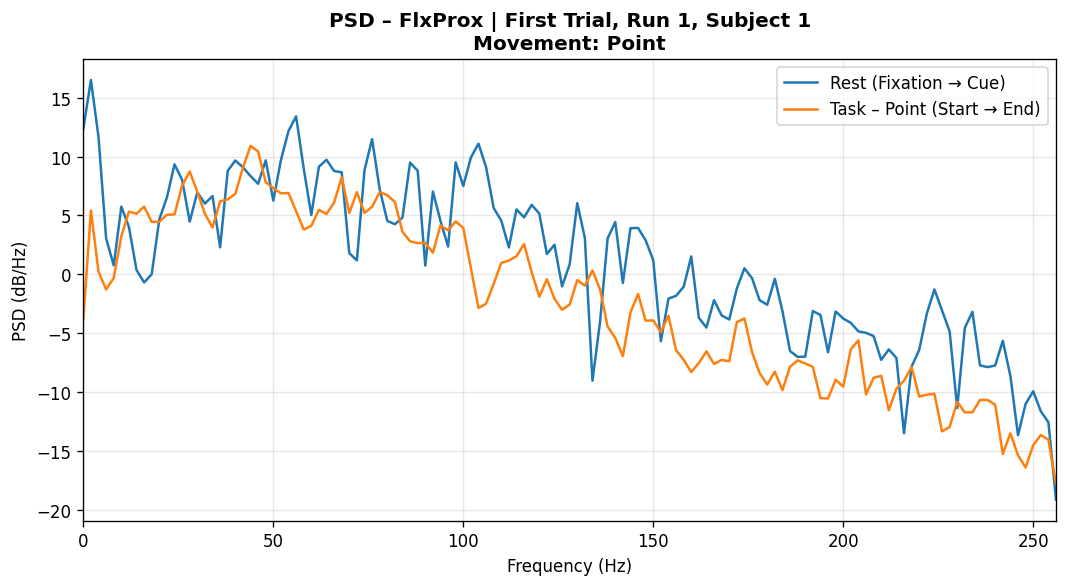

In [36]:
# ── PSD: Rest vs Task for the remaining 3 channels ───────────────────────────
other_channels = [ch for ch in range(len(labels)) if ch != ch_flxdist]

for ch in other_channels:
    emg_rest_ch = emg[rest_start:rest_end, ch]
    emg_task_ch = emg[task_start:task_end, ch]

    nperseg_ch = min(256, len(emg_rest_ch), len(emg_task_ch))
    f_r, psd_r = welch(emg_rest_ch, fs=fs, nperseg=nperseg_ch)
    f_t, psd_t = welch(emg_task_ch, fs=fs, nperseg=nperseg_ch)

    psd_r_db = 10 * np.log10(psd_r)
    psd_t_db = 10 * np.log10(psd_t)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(f_r, psd_r_db, label='Rest (Fixation → Cue)', linewidth=1.5)
    ax.plot(f_t, psd_t_db, label=f'Task – {movement} (Start → End)', linewidth=1.5)

    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD (dB/Hz)')
    ax.set_title(f'PSD – {labels[ch]} | First Trial, Run 1, Subject 1\n'
                 f'Movement: {movement}', fontweight='bold')
    ax.legend()
    ax.set_xlim(0, fs / 2)
    ax.grid(True, which='both', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'psd_rest_vs_task_{labels[ch]}.png', bbox_inches='tight')
    plt.show()

In [37]:
from scipy.signal import butter, sosfiltfilt

# ── Bandpass filter 50-200 Hz ─────────────────────────────────────────────────
def bandpass_filter(emg, fs, lo=50, hi=200, order=4):
    """Zero-phase Butterworth bandpass filter."""
    sos = butter(order, [lo, hi], btype='bandpass', fs=fs, output='sos')
    return sosfiltfilt(sos, emg, axis=0)

# ── Load & filter all runs for both subjects ─────────────────────────────────
# Result: filtered_data[subject_idx][run_idx] is a dict with
#   'emg'    : (n_samples, 4) filtered EMG
#   'fs'     : sampling rate
#   'labels' : channel names
#   'typ'    : event type codes
#   'pos'    : event sample positions

all_runs = [runs_s1, runs_s2]
filtered_data = []

for subj_idx, runs in enumerate(all_runs, start=1):
    subj_runs = []
    for run_idx, run in enumerate(runs):
        emg_filt = bandpass_filter(run['emg'], run['fs'])
        subj_runs.append(dict(
            emg=emg_filt,
            fs=run['fs'],
            labels=run['labels'],
            typ=run['typ'],
            pos=run['pos'],
        ))
    filtered_data.append(subj_runs)
    print(f"Subject {subj_idx}: filtered {len(subj_runs)} runs  "
          f"(fs={subj_runs[0]['fs']} Hz, channels={subj_runs[0]['labels']})")

print(f"\nAccess via filtered_data[subject][run], e.g. "
      f"filtered_data[0][0]['emg'].shape = {filtered_data[0][0]['emg'].shape}")
print(f"filtered_data[0][1]['emg'].shape = {filtered_data[0][1]['emg'].shape}")
print(f"filtered_data[1][0]['emg'].shape = {filtered_data[1][0]['emg'].shape}")
print(f"filtered_data[1][1]['emg'].shape = {filtered_data[1][1]['emg'].shape}")

Subject 1: filtered 6 runs  (fs=512 Hz, channels=['ExtProx', 'ExtDist', 'FlxProx', 'FlxDist'])
Subject 2: filtered 6 runs  (fs=512 Hz, channels=['ExtProx', 'ExtDist', 'FlxProx', 'FlxDist'])

Access via filtered_data[subject][run], e.g. filtered_data[0][0]['emg'].shape = (127488, 4)
filtered_data[0][1]['emg'].shape = (125440, 4)
filtered_data[1][0]['emg'].shape = (127488, 4)
filtered_data[1][1]['emg'].shape = (126464, 4)


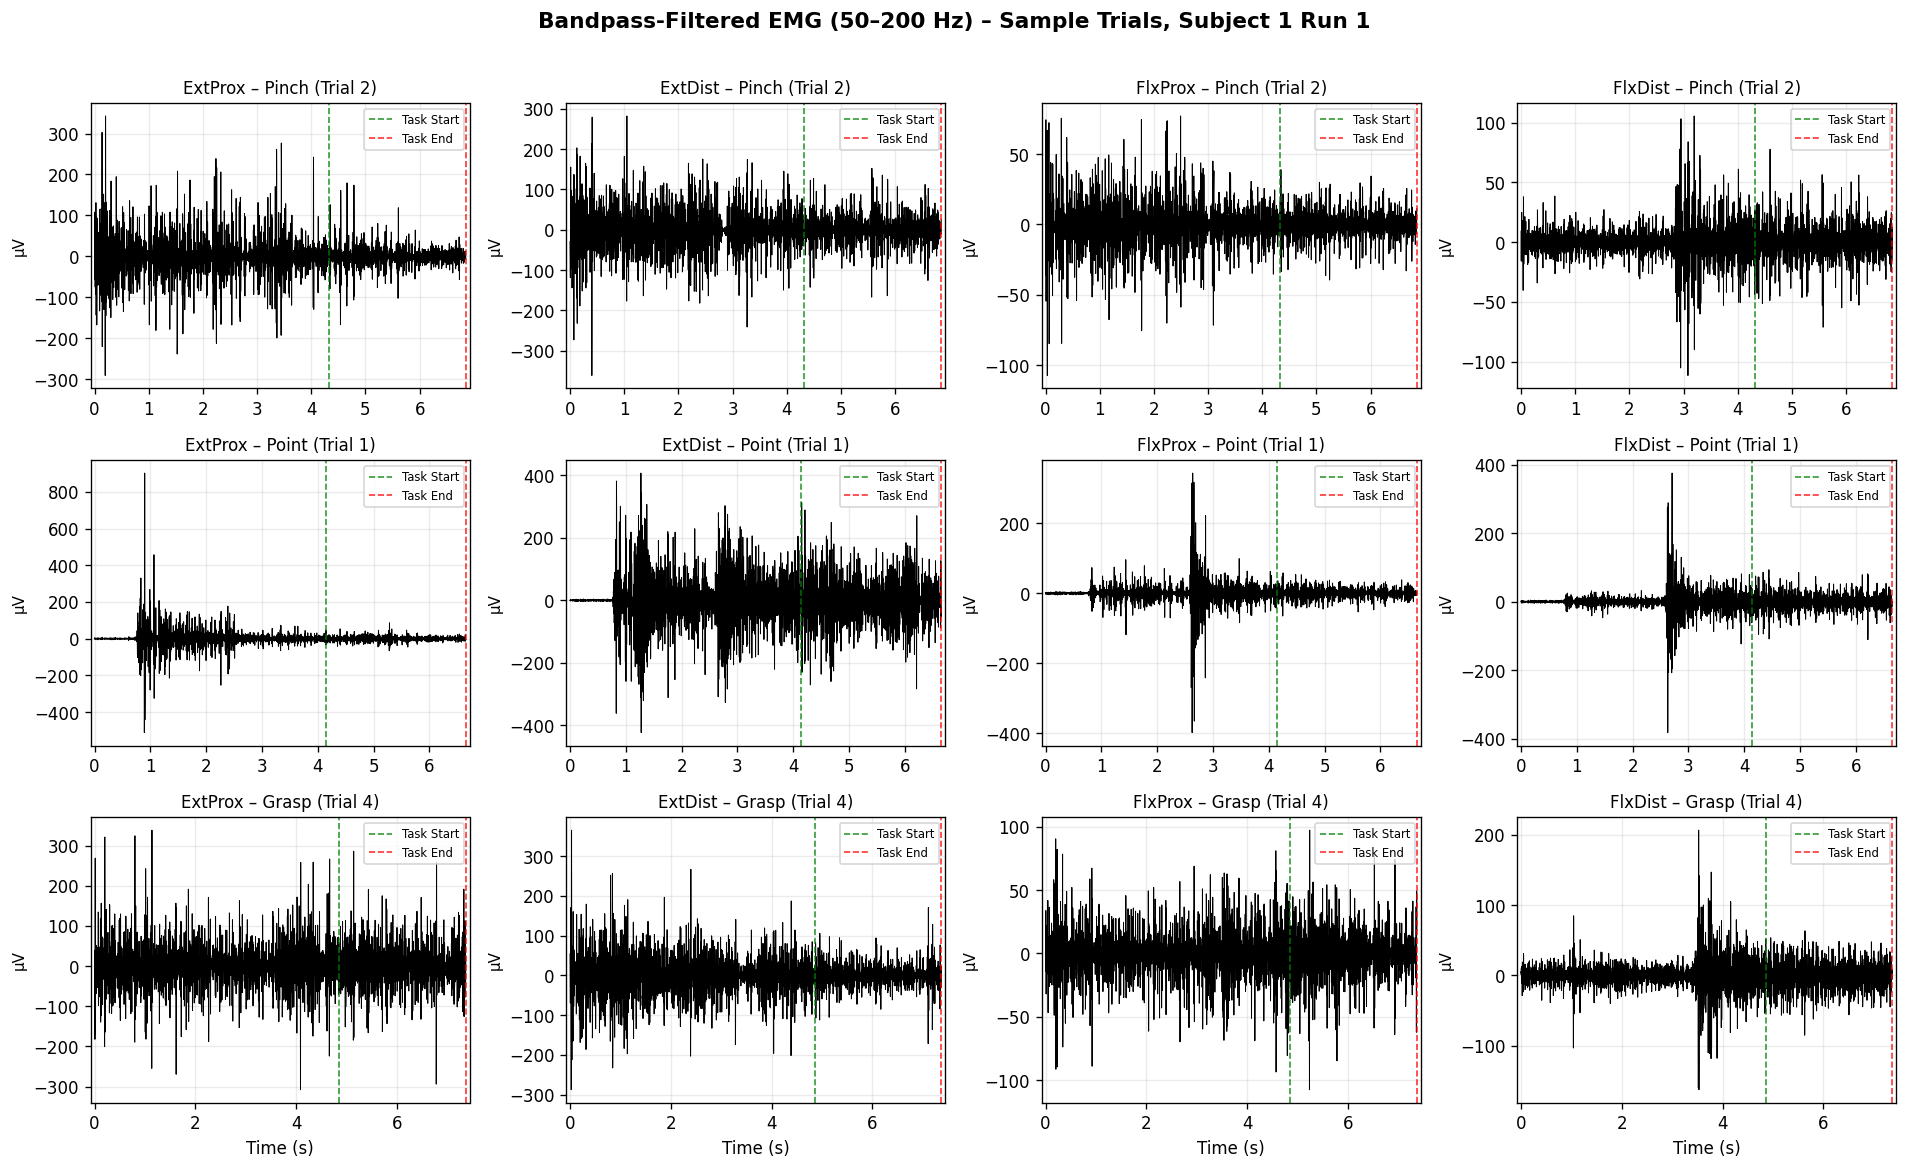

In [38]:
# ── Filtered EMG: sample trials across tasks & channels ──────────────────────
# Show 3 trials (one per movement class) from Subject 1, Run 1
# All 4 channels plotted for each trial.

fd_run = filtered_data[0][0]          # Subject 1, Run 1, filtered
emg_f  = fd_run['emg']
fs_f   = fd_run['fs']
typ_f  = fd_run['typ']
pos_f  = fd_run['pos']
lab_f  = fd_run['labels']

class_map   = {100: 'Pinch', 200: 'Point', 300: 'Grasp'}
cue_codes   = [100, 200, 300]
start_codes = [101, 201, 301]
end_codes   = [102, 202, 302]

# Pick the first trial of each movement class and record its sequential trial number
trial_starts_all = pos_f[typ_f == 1000]
trial_picks = {}   # {movement_name: (trial_start_1000, task_end, trial_num)}
for cue, sc, ec in zip(cue_codes, start_codes, end_codes):
    cue_positions = pos_f[typ_f == cue]
    if len(cue_positions) == 0:
        continue
    first_cue_pos = cue_positions[0]
    t0 = trial_starts_all[trial_starts_all < first_cue_pos][-1]
    trial_num = np.searchsorted(trial_starts_all, t0) + 1   # 1-based
    te_positions = pos_f[typ_f == ec]
    t1 = te_positions[te_positions > first_cue_pos][0]
    trial_picks[class_map[cue]] = (t0, t1, trial_num)

n_moves = len(trial_picks)
n_chs   = len(lab_f)

fig, axes = plt.subplots(n_moves, n_chs, figsize=(16, 3.2 * n_moves),
                         sharex=False, squeeze=False)
fig.suptitle('Bandpass-Filtered EMG (50–200 Hz) – Sample Trials, Subject 1 Run 1',
             fontsize=13, fontweight='bold', y=1.01)

for row, (move_name, (s0, s1, tnum)) in enumerate(trial_picks.items()):
    seg = emg_f[s0:s1+1, :]
    t_seg = np.arange(seg.shape[0]) / fs_f

    mask = (pos_f >= s0) & (pos_f <= s1)
    ev_t = typ_f[mask]
    ev_p = pos_f[mask]

    for col in range(n_chs):
        ax = axes[row, col]
        ax.plot(t_seg, seg[:, col], linewidth=0.6, color='k')
        ax.set_ylabel('µV', fontsize=9)
        ax.set_title(f'{lab_f[col]} – {move_name} (Trial {tnum})', fontsize=10)
        ax.margins(x=0.01)
        ax.grid(True, alpha=0.25)

        for code, samp in zip(ev_t, ev_p):
            rel = (samp - s0) / fs_f
            if code in (101, 201, 301):
                ax.axvline(rel, color='green', ls='--', lw=1, alpha=0.8, label='Task Start')
            elif code in (102, 202, 302):
                ax.axvline(rel, color='red', ls='--', lw=1, alpha=0.8, label='Task End')

        handles, lbls = ax.get_legend_handles_labels()
        by_label = dict(zip(lbls, handles))
        if by_label:
            ax.legend(by_label.values(), by_label.keys(), fontsize=7, loc='upper right')

for col in range(n_chs):
    axes[-1, col].set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig('filtered_emg_sample_trials.png', bbox_inches='tight')
plt.show()

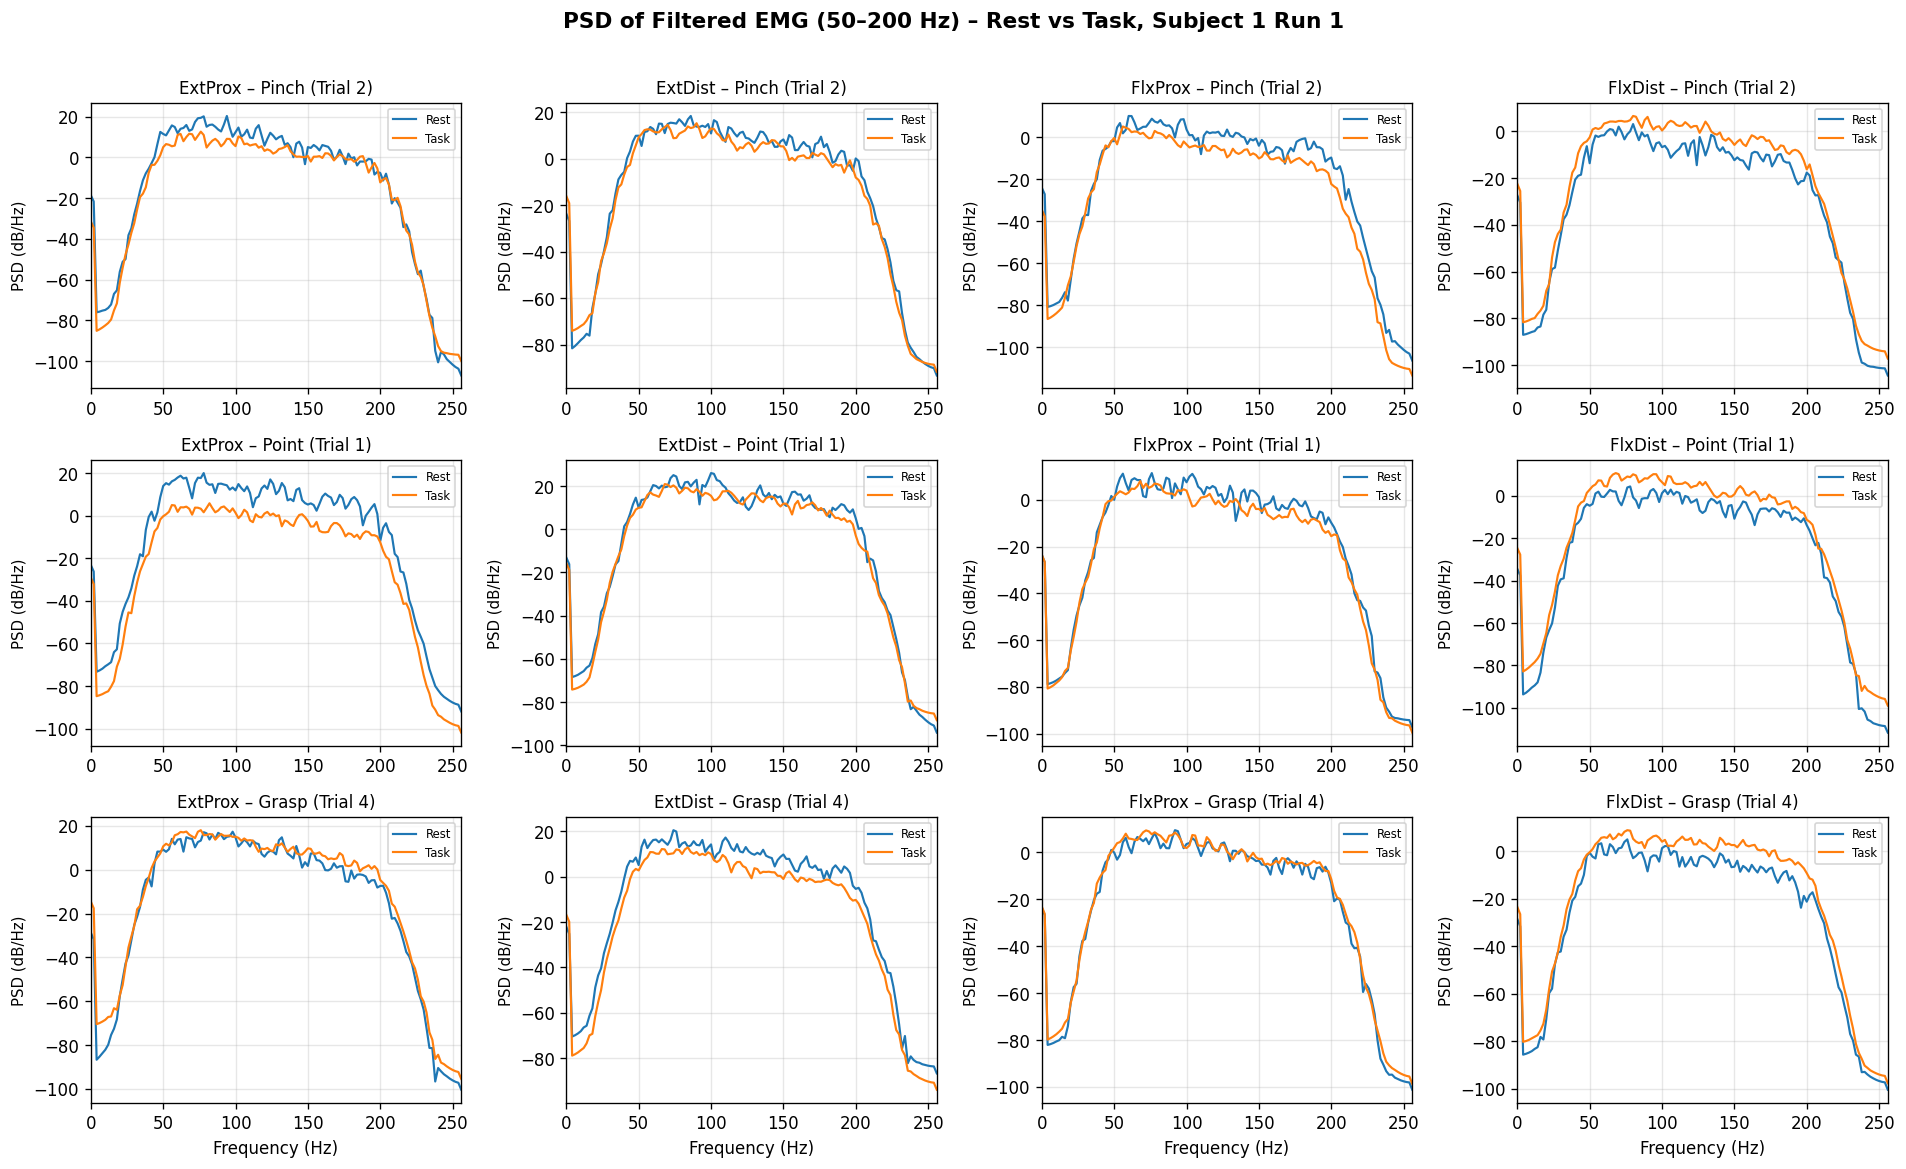

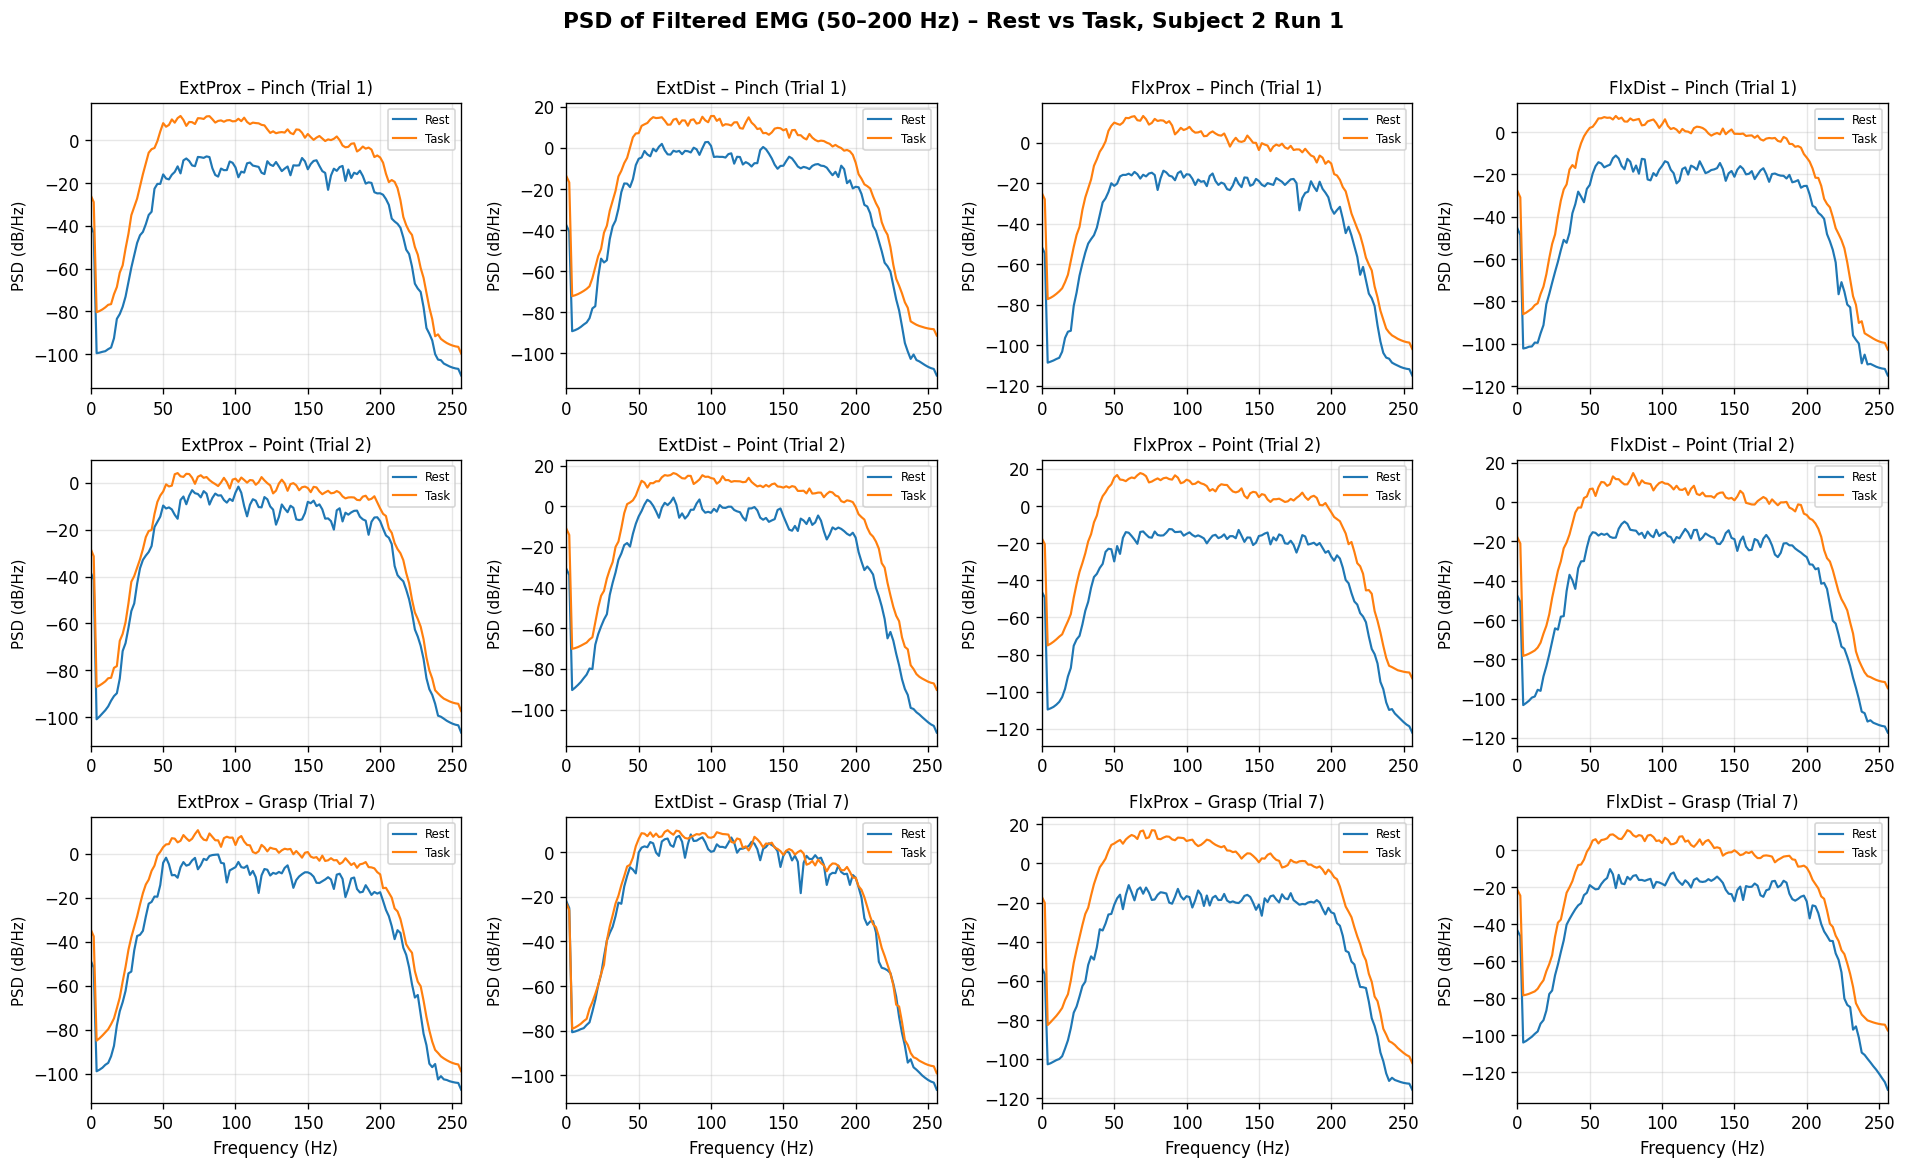

In [39]:
# ── PSD of filtered EMG: same sample trials (Rest vs Task), all 4 channels ───
from scipy.signal import welch

for subj_idx in range(2):
    fd_run_s = filtered_data[subj_idx][0]    # Run 1 for each subject, filtered
    emg_f_s  = fd_run_s['emg']
    fs_f_s   = fd_run_s['fs']
    typ_f_s  = fd_run_s['typ']
    pos_f_s  = fd_run_s['pos']
    lab_f_s  = fd_run_s['labels']

    trial_starts_all_s = pos_f_s[typ_f_s == 1000]
    trial_picks_s = {}
    for cue, sc, ec in zip(cue_codes, start_codes, end_codes):
        cue_positions = pos_f_s[typ_f_s == cue]
        if len(cue_positions) == 0:
            continue
        first_cue_pos = cue_positions[0]
        t0 = trial_starts_all_s[trial_starts_all_s < first_cue_pos][-1]
        trial_num = np.searchsorted(trial_starts_all_s, t0) + 1
        te_positions = pos_f_s[typ_f_s == ec]
        t1 = te_positions[te_positions > first_cue_pos][0]
        trial_picks_s[class_map[cue]] = (t0, t1, trial_num)

    n_moves_s = len(trial_picks_s)
    n_chs_s   = len(lab_f_s)

    fig, axes = plt.subplots(n_moves_s, n_chs_s, figsize=(16, 3.2 * n_moves_s),
                             sharex=False, squeeze=False)
    fig.suptitle(f'PSD of Filtered EMG (50–200 Hz) – Rest vs Task, Subject {subj_idx + 1} Run 1',
                 fontsize=13, fontweight='bold', y=1.01)

    for row, (move_name, (s0, s1, tnum)) in enumerate(trial_picks_s.items()):
        mask = (pos_f_s >= s0) & (pos_f_s <= s1)
        ev_t = typ_f_s[mask]
        ev_p = pos_f_s[mask]

        fix_pos = ev_p[ev_t == 768][0]
        cue_pos = ev_p[(ev_t == 100) | (ev_t == 200) | (ev_t == 300)][0]
        tsk_pos = ev_p[(ev_t == 101) | (ev_t == 201) | (ev_t == 301)][0]
        end_pos = ev_p[(ev_t == 102) | (ev_t == 202) | (ev_t == 302)][0]

        for col in range(n_chs_s):
            rest_seg = emg_f_s[fix_pos:cue_pos, col]
            task_seg = emg_f_s[tsk_pos:end_pos, col]

            nperseg_psd = min(256, len(rest_seg), len(task_seg))
            f_r, psd_r = welch(rest_seg, fs=fs_f_s, nperseg=nperseg_psd)
            f_t, psd_t = welch(task_seg, fs=fs_f_s, nperseg=nperseg_psd)

            ax = axes[row, col]
            ax.plot(f_r, 10 * np.log10(psd_r), label='Rest', linewidth=1.3)
            ax.plot(f_t, 10 * np.log10(psd_t), label='Task', linewidth=1.3)
            ax.set_title(f'{lab_f_s[col]} – {move_name} (Trial {tnum})', fontsize=10)
            ax.set_ylabel('PSD (dB/Hz)', fontsize=9)
            ax.set_xlim(0, fs_f_s / 2)
            ax.grid(True, which='both', alpha=0.3)
            ax.legend(fontsize=7, loc='upper right')

    for col in range(n_chs_s):
        axes[-1, col].set_xlabel('Frequency (Hz)')

    plt.tight_layout()
    plt.savefig(f'psd_filtered_sample_trials_S{subj_idx + 1}.png', bbox_inches='tight')
    plt.show()

In [40]:
# ── Extract per-trial task segments (Task Start → Task End) ───────────────────
# For each subject: a list of (emg_channels, task_label) tuples.
#   emg_channels : list of 4 arrays, one per channel (variable length)
#   task_label   : str – 'Pinch', 'Point', or 'Grasp'
# Length = total trials across all runs.

task_class = {101: 'Pinch', 201: 'Point', 301: 'Grasp'}
task_start_codes = {101, 201, 301}
task_end_codes   = {102, 202, 302}

trials_s1 = []
trials_s2 = []

for subj_trials, subj_runs in [(trials_s1, filtered_data[0]),
                                (trials_s2, filtered_data[1])]:
    for run in subj_runs:
        typ_r = run['typ']
        pos_r = run['pos']
        emg_r = run['emg']

        starts = pos_r[np.isin(typ_r, list(task_start_codes))]
        ends   = pos_r[np.isin(typ_r, list(task_end_codes))]
        codes  = typ_r[np.isin(typ_r, list(task_start_codes))]

        for s_pos, e_pos, s_code in zip(starts, ends, codes):
            channels = [emg_r[s_pos:e_pos, ch] for ch in range(4)]
            subj_trials.append((channels, task_class[s_code]))

print(f"Subject 1: {len(trials_s1)} trials")
print(f"Subject 2: {len(trials_s2)} trials")
print(f"\nSample lengths (Subject 1, first 6 trials):")
for i, (chs, lbl) in enumerate(trials_s1[:6]):
    print(f"  Trial {i+1}: {lbl:6s} – {len(chs[0])} samples/channel")

Subject 1: 180 trials
Subject 2: 180 trials

Sample lengths (Subject 1, first 6 trials):
  Trial 1: Point  – 1286 samples/channel
  Trial 2: Pinch  – 1294 samples/channel
  Trial 3: Pinch  – 1283 samples/channel
  Trial 4: Grasp  – 1283 samples/channel
  Trial 5: Pinch  – 1284 samples/channel
  Trial 6: Point  – 1283 samples/channel


## 2.2 Feature Extraction

**Features**: MAV (Mean Absolute Value) and SSC (Slope Sign Changes), computed over sliding windows.

Window size and overlap will be optimized via run-wise cross-validation in §2.4. For the scatter plots below, a preliminary window of 200 samples with 50 % overlap is used.

In [41]:
# ── 2.2.1  Feature functions ──────────────────────────────────────────────────
def extract_features(signal, win_len, overlap_frac):
    """Compute MAV and SSC (Slope Sign Changes) over sliding windows on a 1-D signal."""
    step = max(1, int(win_len * (1 - overlap_frac)))
    n_win = max(0, (len(signal) - win_len) // step + 1)
    if n_win == 0:
        return np.array([]), np.array([])
    mav = np.empty(n_win)
    ssc = np.empty(n_win)
    for i in range(n_win):
        s = i * step
        w = signal[s:s + win_len]
        mav[i] = np.mean(np.abs(w))
        # SSC: count sign changes in the first-order difference
        diff = np.diff(w)
        ssc[i] = np.sum(diff[:-1] * diff[1:] < 0)
    return mav, ssc

print("extract_features() defined.")

extract_features() defined.


In [42]:
# ── 2.2.2  Compute features for all subjects, classes, sensors ───────────────
WIN_VIS = 350     # samples – preliminary; optimal found via CV in §2.4
OVL_VIS = 0.75

classes   = ['Pinch', 'Point', 'Grasp']
ch_names  = filtered_data[0][0]['labels']

# feat_data[subj][cls][ch] = {'mav': array, 'ssc': array}
feat_data = []
for subj_idx, trials in enumerate([trials_s1, trials_s2]):
    subj = {cls: {ch: {'mav': [], 'ssc': []} for ch in range(4)} for cls in classes}
    for channels, label in trials:
        for ch in range(4):
            m, s = extract_features(channels[ch], WIN_VIS, OVL_VIS)
            if len(m) > 0:
                subj[label][ch]['mav'].extend(m)
                subj[label][ch]['ssc'].extend(s) 
    for cls in classes:
        for ch in range(4):
            subj[cls][ch]['mav'] = np.array(subj[cls][ch]['mav'])
            subj[cls][ch]['ssc'] = np.array(subj[cls][ch]['ssc'])
    feat_data.append(subj)

print(f"Feature windows (win={WIN_VIS}, overlap={OVL_VIS:.0%}):")
for s in range(2):
    for cls in classes:
        n = len(feat_data[s][cls][0]['mav'])
        print(f"  Subject {s+1} – {cls}: {n} windows")

Feature windows (win=350, overlap=75%):
  Subject 1 – Pinch: 660 windows
  Subject 1 – Point: 660 windows
  Subject 1 – Grasp: 660 windows
  Subject 2 – Pinch: 660 windows
  Subject 2 – Point: 660 windows
  Subject 2 – Grasp: 660 windows


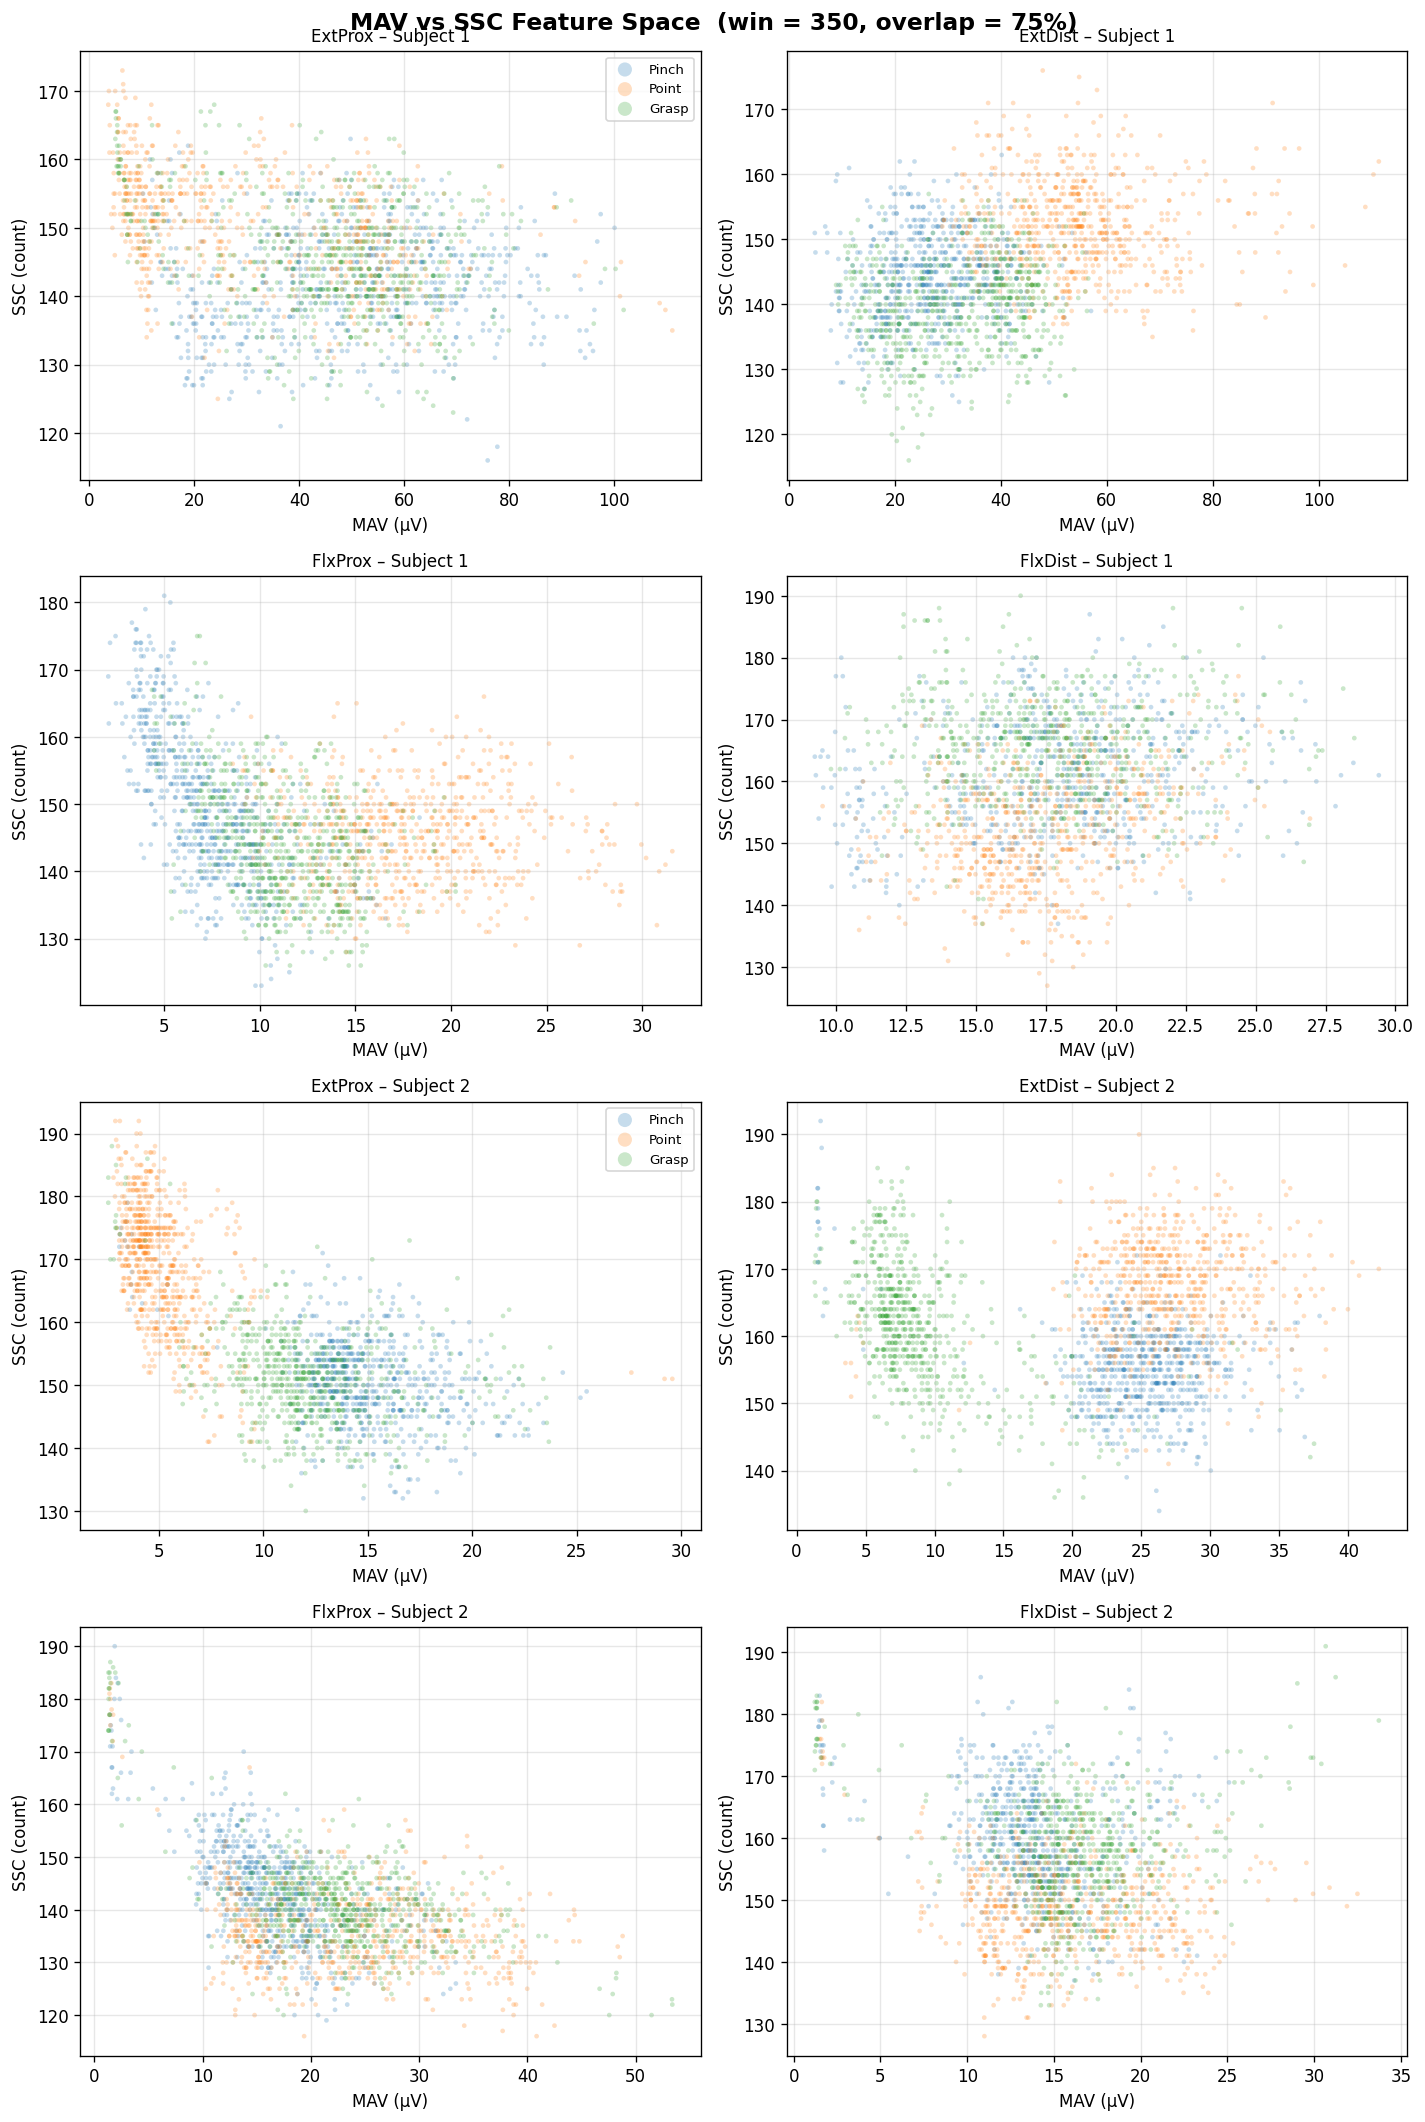

In [43]:
# ── 2.2.3  Scatter plots: MAV vs SSC per sensor, both subjects ───────────────
colors_cls = {'Pinch': 'tab:blue', 'Point': 'tab:orange', 'Grasp': 'tab:green'}

fig, axes = plt.subplots(4, 2, figsize=(12, 18), squeeze=False)
fig.suptitle(f'MAV vs SSC Feature Space  (win = {WIN_VIS}, overlap = {OVL_VIS:.0%})',
             fontsize=14, fontweight='bold')

for subj in range(2):
    for ch in range(4):
        row = subj * 2 + ch // 2
        col = ch % 2
        ax = axes[row, col]
        for cls in classes:
            ax.scatter(feat_data[subj][cls][ch]['mav'],
                       feat_data[subj][cls][ch]['ssc'],
                       c=colors_cls[cls], label=cls,
                       alpha=0.25, s=8, edgecolors='none')
        ax.set_xlabel('MAV (µV)')
        ax.set_ylabel('SSC (count)')
        ax.set_title(f'{ch_names[ch]} – Subject {subj + 1}', fontsize=10)
        if ch == 0:
            ax.legend(fontsize=8, markerscale=3)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('2_2_scatter_mav_ssc.png', bbox_inches='tight')
plt.show()

## 2.3 Average Patterns

Pipeline for MAV envelope (**Subject 1, Proximal Flexor only**):

1. Bandpass-filtered EMG (already computed)
2. Rectify (take absolute value)
3. Lowpass filter at 5 Hz (temporal smoothing ≈ moving average)
4. Extract task segments (Task Start → Task End)
5. Align and average across trials of the same movement class

In [44]:
# ── 2.3.1  Compute MAV envelopes: |bandpassed EMG| → lowpass 5 Hz ────────────
ch_flxprox = ch_names.index('FlxProx')

def mav_envelope(signal, fs, cutoff=5, order=4):
    """Rectify + lowpass filter to get a smooth MAV envelope."""
    rectified = np.abs(signal)
    sos = butter(order, cutoff, btype='low', fs=fs, output='sos')
    return sosfiltfilt(sos, rectified)

task_class_env = {101: 'Pinch', 201: 'Point', 301: 'Grasp'}
mav_trials_env = {'Pinch': [], 'Point': [], 'Grasp': []}

for run in filtered_data[0]:                       # Subject 1 only
    env = mav_envelope(run['emg'][:, ch_flxprox], run['fs'])
    typ_r, pos_r = run['typ'], run['pos']

    starts = pos_r[np.isin(typ_r, [101, 201, 301])]
    ends   = pos_r[np.isin(typ_r, [102, 202, 302])]
    codes  = typ_r[np.isin(typ_r, [101, 201, 301])]

    for s_pos, e_pos, s_code in zip(starts, ends, codes):
        mav_trials_env[task_class_env[s_code]].append(env[s_pos:e_pos])

# Average across trials (truncate to shortest trial per class)
fs_s1   = filtered_data[0][0]['fs']
avg_mav = {}
for cls in classes:
    min_len = min(len(t) for t in mav_trials_env[cls])
    stacked = np.array([t[:min_len] for t in mav_trials_env[cls]])
    avg_mav[cls] = stacked.mean(axis=0)
    print(f"{cls}: {len(mav_trials_env[cls])} trials, "
          f"truncated to {min_len} samples ({min_len / fs_s1:.2f} s)")

Pinch: 60 trials, truncated to 1282 samples (2.50 s)
Point: 60 trials, truncated to 1283 samples (2.51 s)
Grasp: 60 trials, truncated to 1282 samples (2.50 s)


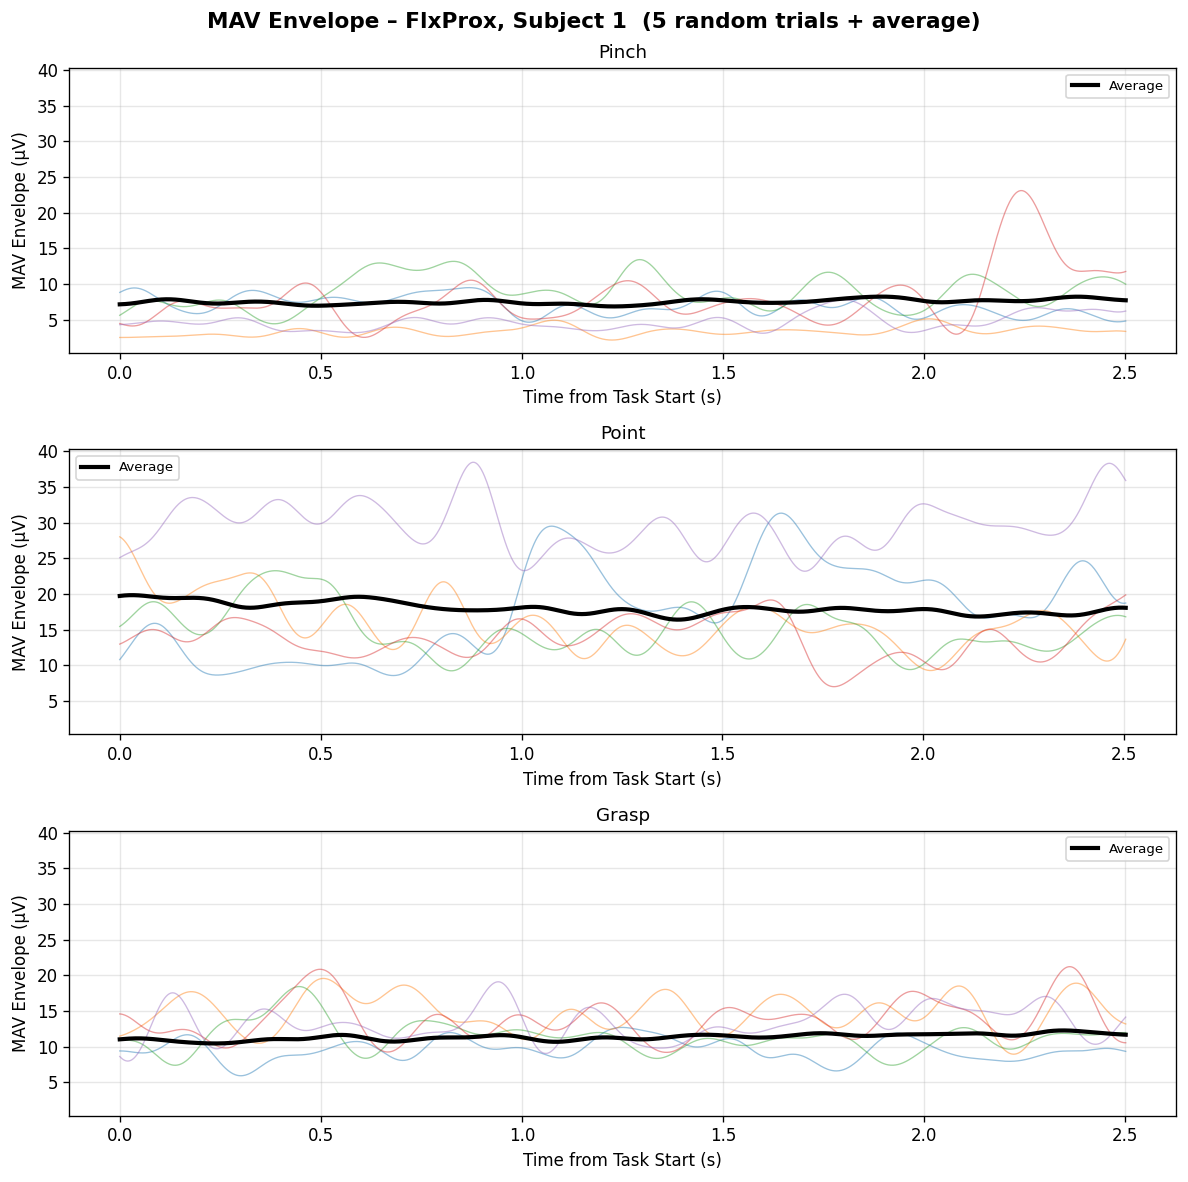

In [45]:
# ── 2.3.2  Plot 5 random trials + average MAV for each movement ──────────────
np.random.seed(42)

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharey=True)
fig.suptitle('MAV Envelope – FlxProx, Subject 1  (5 random trials + average)',
             fontsize=13, fontweight='bold')

for ax, cls in zip(axes, classes):
    n_tr    = len(mav_trials_env[cls])
    idxs    = np.random.choice(n_tr, size=min(5, n_tr), replace=False)
    min_len = len(avg_mav[cls])
    t_ax    = np.arange(min_len) / fs_s1

    for idx in idxs:
        ax.plot(t_ax, mav_trials_env[cls][idx][:min_len],
                alpha=0.45, linewidth=0.8)
    ax.plot(t_ax, avg_mav[cls], color='black', linewidth=2.5, label='Average')

    ax.set_title(cls, fontsize=11)
    ax.set_xlabel('Time from Task Start (s)')
    ax.set_ylabel('MAV Envelope (µV)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('2_3_avg_mav_patterns.png', bbox_inches='tight')
plt.show()

### Comments on Average Patterns

**2.3.2 – Individual trials vs. average**: The individual trials show substantial variability in amplitude, but the overall temporal shape is consistent within each movement class — a burst of activity shortly after task onset that decays towards task end. The average pattern captures this common waveform while the per-trial noise cancels out, demonstrating the SNR improvement from trial averaging.

**2.3.3 – Comparison with 2.2 feature distributions**: The MAV feature distributions in the 2.2 scatter plots represent *windowed* MAV values pooled over all time points during a task, collapsing temporal structure. The average patterns here reveal that MAV is not constant during a movement — it rises and falls. This temporal variation explains the spread in the scatter plots: windows taken near peak contraction produce high MAV values, while windows near the edges of the task produce lower values, broadening the per-class distributions. SSC, meanwhile, captures waveform complexity rather than amplitude — it remains relatively stable across the task window but differs between classes due to distinct motor-unit firing patterns.

## 2.4 Classification

**Setup**: 3-class classification (Pinch / Point / Grasp) using MAV + SSC features from all 4 channels (8 features per window).

**Cross-validation**: Run-wise leave-one-out on the **first 5 runs**, with grid search over:
- **Window sizes**: 50 – 350 samples (step 25)
- **Overlap fractions**: 0 %, 25 %, 50 %, 75 %
- **Classifiers**: Linear LDA, plus three 1-D CNN architectures of increasing depth:
  - **CNN-S** (shallow): 1 conv layer (16 filters)
  - **CNN-M** (medium): 2 conv layers (16 → 32 filters)
  - **CNN-L** (deep): 3 conv layers (16 → 32 → 64 filters)

All CNNs use kernel size 3, BatchNorm + ReLU after each conv, adaptive average pooling, and a final linear layer. Trained with Adam (lr = 1e-3) for 80 epochs per fold.

**Advantage of run-wise CV**: Using entire runs as CV folds prevents temporal-correlation leakage. Adjacent windows within the same run are highly correlated; if they appeared in both train and test sets, accuracy estimates would be inflated. Run-wise CV better predicts performance on new, unseen recording sessions — the realistic deployment scenario for a real-time BCI.

Using device: cuda
  GPU: NVIDIA GeForce RTX 3060 Ti


[Part A] Subject 1:   0%|          | 0/52 [00:00<?, ?combo/s]

Subject 1 – Best: win=325, overlap=75%, LDA, accuracy = 0.840 ± 0.076


[Part A] Subject 2:   0%|          | 0/52 [00:00<?, ?combo/s]

Subject 2 – Best: win=200, overlap=0%, LDA, accuracy = 0.961 ± 0.040


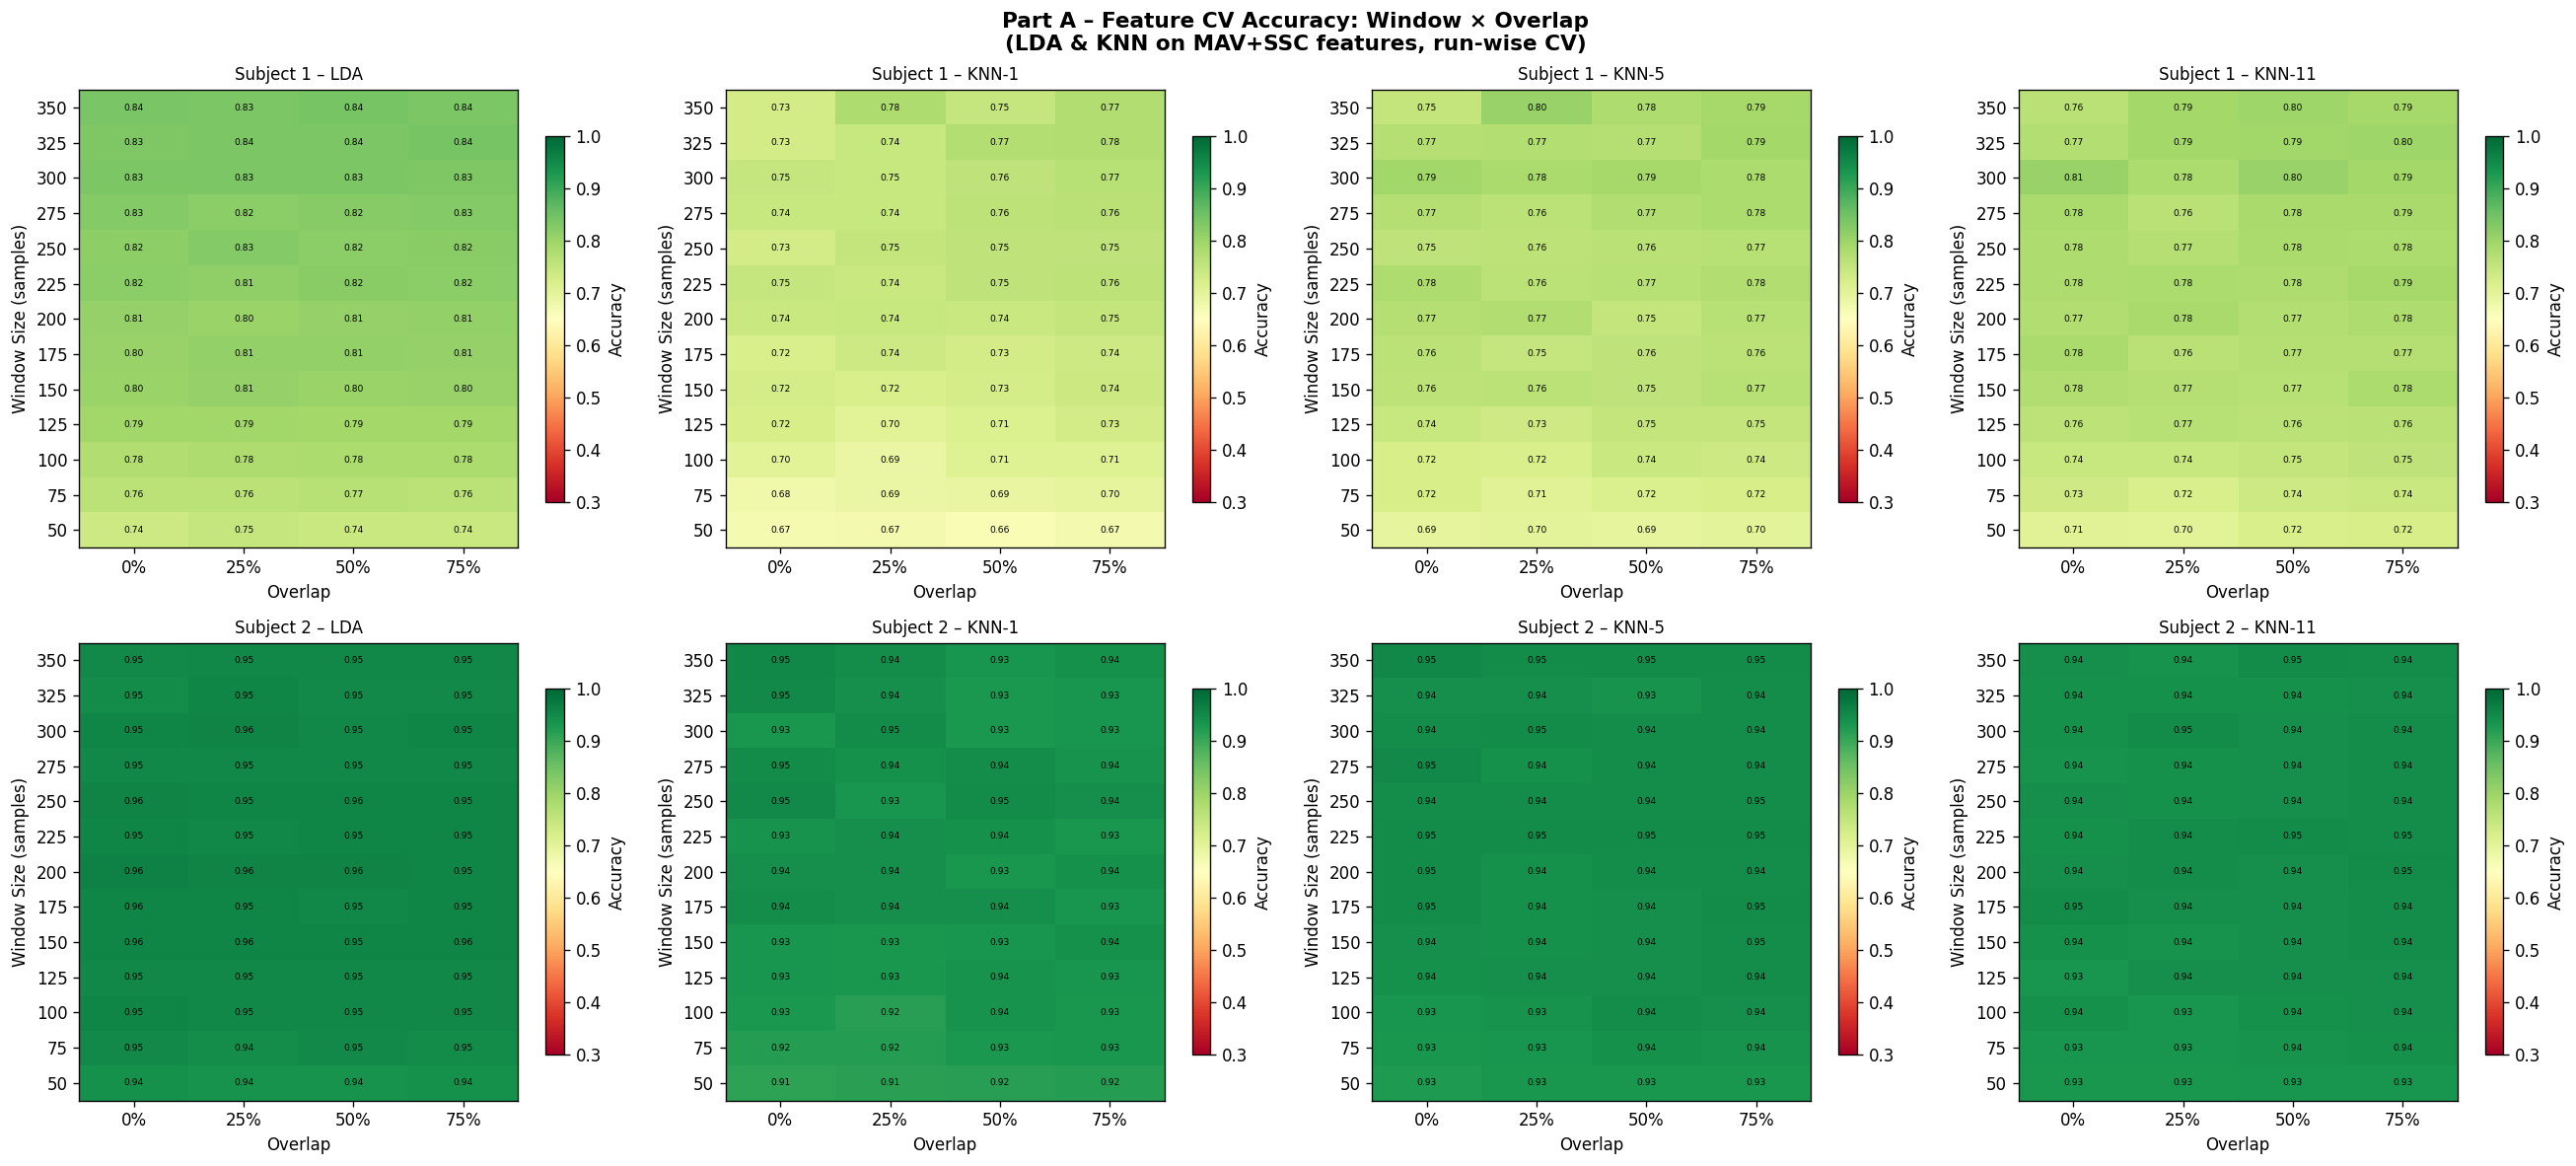

In [15]:
# ── 2.4.1  Setup + Part A: LDA vs KNN on extracted features ──────────────────
import torch
import torch.nn as nn
from torch.amp import autocast, GradScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True

use_amp = device.type == 'cuda'

win_sizes     = [50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300, 325, 350]
overlap_fracs = [0, 0.25, 0.5, 0.75]
k_values      = [1, 3, 5, 7, 11, 15]


def extract_run_Xy(run, win_len, ovl_frac, raw=False):
    """Extract windowed data from one run.

    raw=False : X is (n_windows, 8)           — [MAV×4, SSC×4] feature vectors
    raw=True  : X is (n_windows, 4, win_len)  — raw EMG, channels-first
    """
    typ_r, pos_r, emg_r = run['typ'], run['pos'], run['emg']
    task_code = {101: 0, 201: 1, 301: 2}
    step = max(1, int(win_len * (1 - ovl_frac)))

    s_mask = np.isin(typ_r, [101, 201, 301])
    e_mask = np.isin(typ_r, [102, 202, 302])
    starts, ends, codes = pos_r[s_mask], pos_r[e_mask], typ_r[s_mask]

    X_list, y_list = [], []
    for s_pos, e_pos, s_code in zip(starts, ends, codes):
        seg = emg_r[s_pos:e_pos, :]                     # (n_samples, 4)
        n_win = max(0, (len(seg) - win_len) // step + 1)
        if n_win == 0:
            continue

        if raw:
            for w in range(n_win):
                s = w * step
                X_list.append(seg[s:s + win_len, :].T.astype(np.float32))  # (4, win_len)
                y_list.append(task_code[s_code])
        else:
            ch_feats, n_win_min = [], n_win
            for ch in range(4):
                m, r = extract_features(seg[:, ch], win_len, ovl_frac)
                ch_feats.append((m, r))
                n_win_min = min(n_win_min, len(m))
            for w in range(n_win_min):
                row = ([ch_feats[c][0][w] for c in range(4)] +
                       [ch_feats[c][1][w] for c in range(4)])
                X_list.append(row)
                y_list.append(task_code[s_code])

    if X_list:
        return np.array(X_list), np.array(y_list)
    shape = (0, 4, win_len) if raw else (0, 8)
    return np.empty(shape, dtype=np.float32), np.array([], dtype=int)


# ── Part A grid search ────────────────────────────────────────────────────────
results_feat = {}

for subj_idx, subj_runs in enumerate(filtered_data):
    n_cv    = min(5, len(subj_runs))
    cv_runs = subj_runs[:n_cv]
    results = []
    n_total = len(win_sizes) * len(overlap_fracs)

    pbar = tqdm(total=n_total, desc=f'[Part A] Subject {subj_idx + 1}', unit='combo')

    for win_len in win_sizes:
        for ovl in overlap_fracs:
            pbar.set_postfix(win=win_len, ovl=f'{ovl:.0%}')
            run_Xy = [extract_run_Xy(r, win_len, ovl, raw=False) for r in cv_runs]

            clf_accs = {'LDA': [], **{f'KNN-{k}': [] for k in k_values}}

            for test_r in range(n_cv):
                train_idx = [i for i in range(n_cv) if i != test_r]
                Xtr_parts = [run_Xy[i][0] for i in train_idx if len(run_Xy[i][0]) > 0]
                ytr_parts = [run_Xy[i][1] for i in train_idx if len(run_Xy[i][1]) > 0]
                if not Xtr_parts:
                    continue
                X_train = np.vstack(Xtr_parts)
                y_train = np.concatenate(ytr_parts)
                X_test, y_test = run_Xy[test_r]
                if len(X_test) == 0:
                    continue

                scaler   = StandardScaler()
                X_tr_s   = scaler.fit_transform(X_train)
                X_te_s   = scaler.transform(X_test)

                try:
                    lda = LinearDiscriminantAnalysis()
                    lda.fit(X_tr_s, y_train)
                    clf_accs['LDA'].append(lda.score(X_te_s, y_test))
                except Exception:
                    pass

                for k in k_values:
                    try:
                        knn = KNeighborsClassifier(n_neighbors=k)
                        knn.fit(X_tr_s, y_train)
                        clf_accs[f'KNN-{k}'].append(knn.score(X_te_s, y_test))
                    except Exception:
                        pass

            for clf_name, accs in clf_accs.items():
                if accs:
                    results.append((win_len, ovl, clf_name,
                                    np.mean(accs), np.std(accs)))
            pbar.update(1)

    pbar.close()
    results_feat[subj_idx] = results
    best = max(results, key=lambda x: x[3])
    print(f"Subject {subj_idx + 1} – Best: win={best[0]}, overlap={best[1]:.0%}, "
          f"{best[2]}, accuracy = {best[3]:.3f} ± {best[4]:.3f}")


# ── Part A heatmaps (LDA + representative K values) ──────────────────────────
clf_show = ['LDA', 'KNN-1', 'KNN-5', 'KNN-11']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Part A – Feature CV Accuracy: Window × Overlap\n'
             '(LDA & KNN on MAV+SSC features, run-wise CV)',
             fontsize=13, fontweight='bold')

for subj_idx in range(2):
    for col, clf_name in enumerate(clf_show):
        ax = axes[subj_idx, col]
        acc_grid = np.full((len(win_sizes), len(overlap_fracs)), np.nan)
        for w, o, c, a, s in results_feat[subj_idx]:
            if c == clf_name:
                acc_grid[win_sizes.index(w), overlap_fracs.index(o)] = a

        im = ax.imshow(acc_grid, aspect='auto', cmap='RdYlGn',
                       vmin=0.3, vmax=1.0, origin='lower')
        ax.set_xticks(range(len(overlap_fracs)))
        ax.set_xticklabels([f'{o:.0%}' for o in overlap_fracs])
        ax.set_yticks(range(len(win_sizes)))
        ax.set_yticklabels(win_sizes)
        ax.set_xlabel('Overlap')
        ax.set_ylabel('Window Size (samples)')
        ax.set_title(f'Subject {subj_idx + 1} – {clf_name}', fontsize=10)

        for wi in range(len(win_sizes)):
            for oi in range(len(overlap_fracs)):
                v = acc_grid[wi, oi]
                if not np.isnan(v):
                    ax.text(oi, wi, f'{v:.2f}', ha='center', va='center',
                            fontsize=5.5, color='black')
        fig.colorbar(im, ax=ax, shrink=0.8, label='Accuracy')

plt.tight_layout()
plt.savefig('2_4a_cv_heatmap_features.png', bbox_inches='tight')
plt.show()

[Part B] Subject 1:   0%|          | 0/52 [00:00<?, ?combo/s]

Subject 1 – Best: win=300, overlap=0%, CNN-L, accuracy = 0.818 ± 0.092


[Part B] Subject 2:   0%|          | 0/52 [00:00<?, ?combo/s]

Subject 2 – Best: win=325, overlap=50%, CNN-L, accuracy = 0.969 ± 0.036


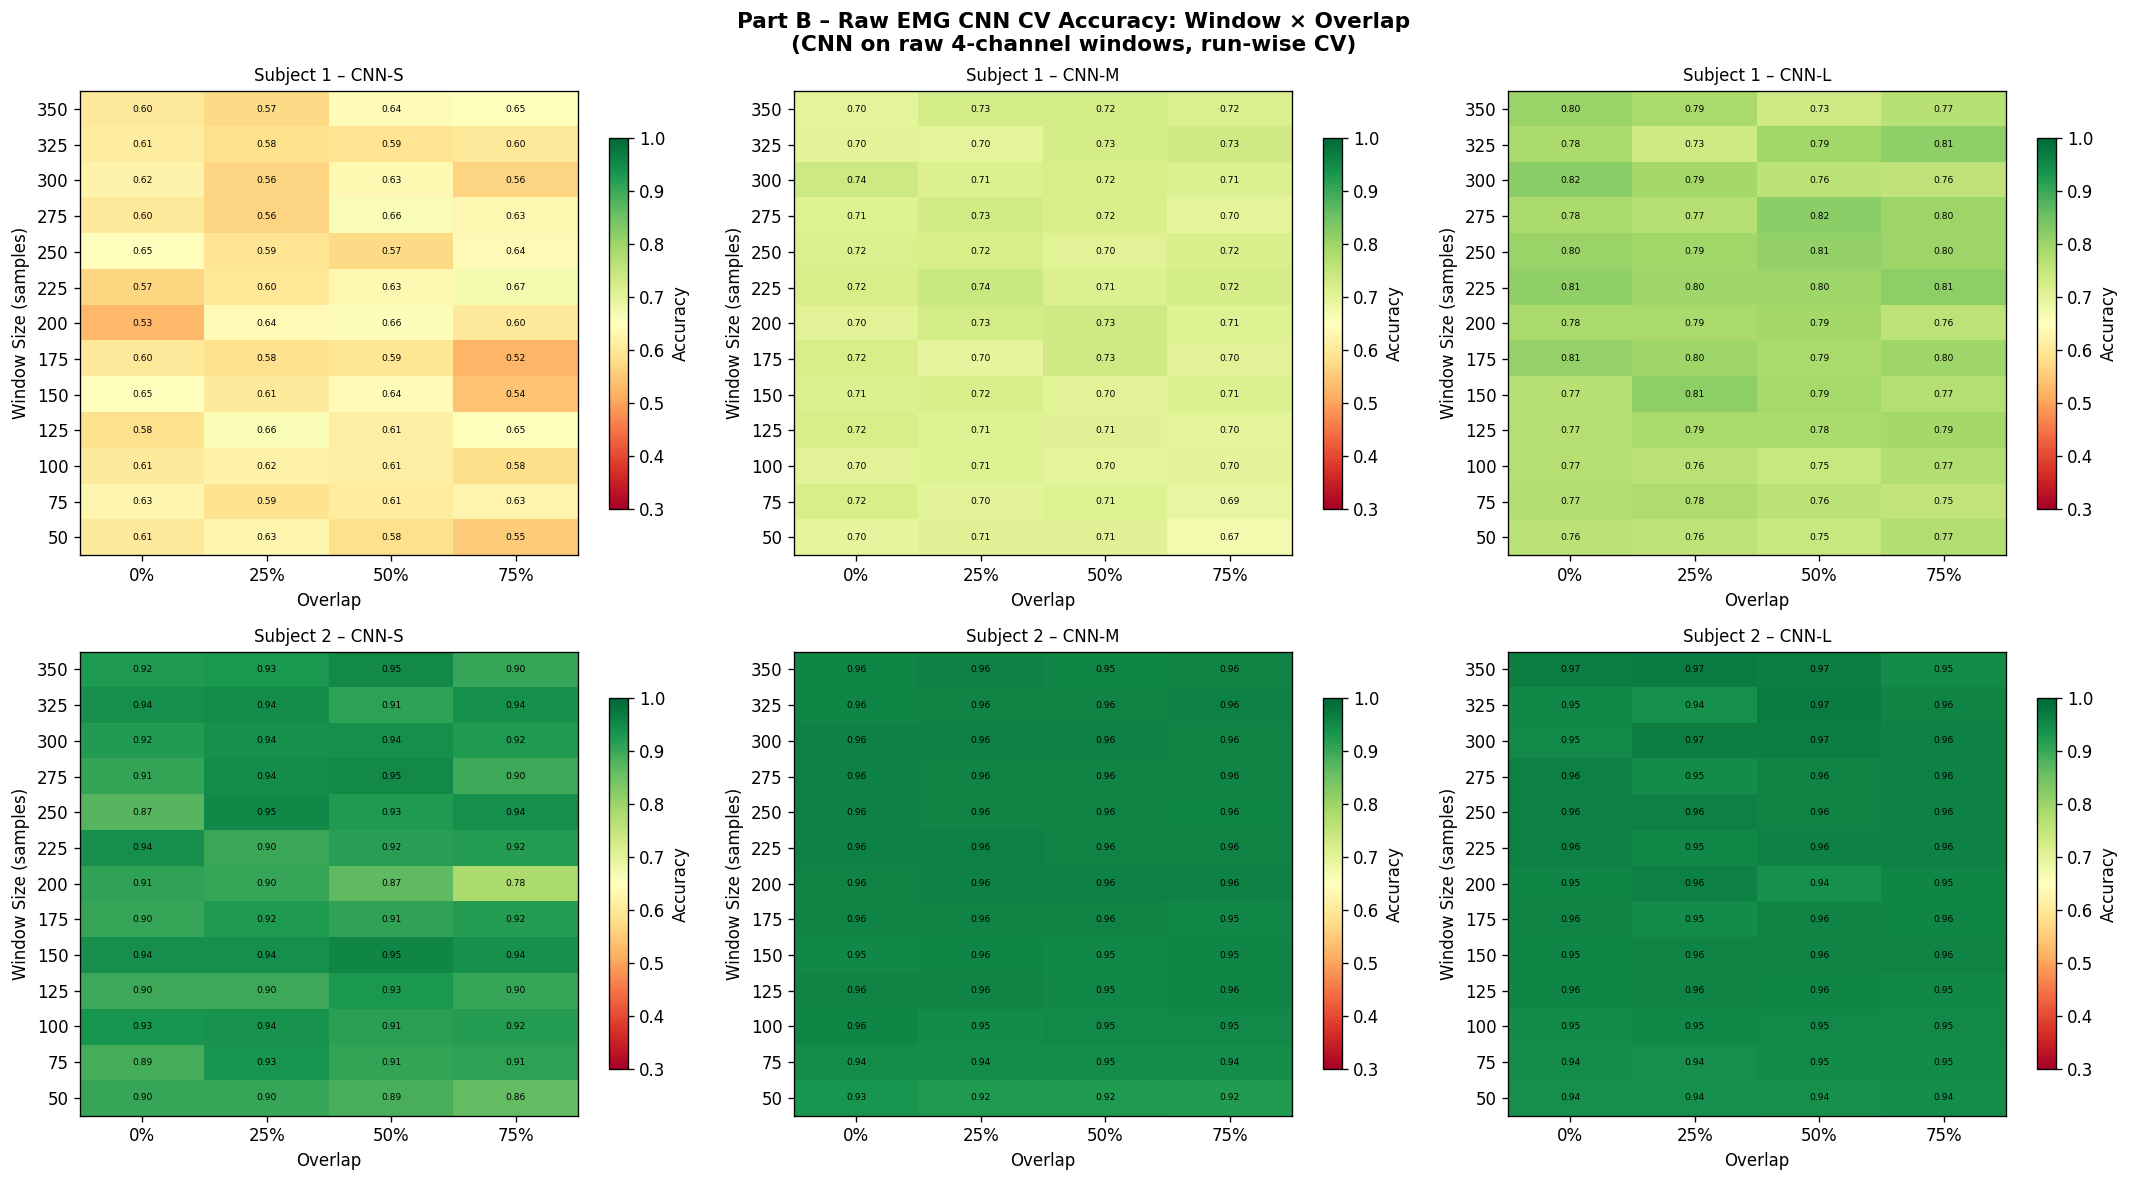

In [16]:
# ── 2.4.2  Part B: CNN on raw EMG windows ────────────────────────────────────

class EMG_CNN_Raw(nn.Module):
    """1-D CNN for multi-channel raw EMG.
    Input: (batch, 4, win_len) — 4 EMG channels, temporal dim last.
    """
    def __init__(self, n_classes=3, channels=(16,), kernel_size=7):
        super().__init__()
        layers = []
        in_ch = 4
        for out_ch in channels:
            layers += [
                nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size,
                          padding=kernel_size // 2),
                nn.BatchNorm1d(out_ch),
                nn.ReLU(),
            ]
            in_ch = out_ch
        layers += [nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                   nn.Linear(in_ch, n_classes)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


CNN_CONFIGS_RAW = {
    'CNN-S': dict(channels=(16,),        kernel_size=7),
    'CNN-M': dict(channels=(16, 32),     kernel_size=7),
    'CNN-L': dict(channels=(16, 32, 64), kernel_size=7),
}


def train_cnn_raw(X_train, y_train, X_test, y_test, cnn_cfg,
                  n_epochs=80, lr=1e-3):
    """Train raw-EMG CNN.  X: (n, 4, win_len), y: (n,)."""
    # Normalise per channel across training windows: shape (1, 4, 1)
    mu    = X_train.mean(axis=(0, 2), keepdims=True)
    sigma = X_train.std(axis=(0, 2),  keepdims=True) + 1e-8
    Xtr = torch.tensor((X_train - mu) / sigma, dtype=torch.float32, device=device)
    ytr = torch.tensor(y_train, dtype=torch.long,  device=device)
    Xte = torch.tensor((X_test  - mu) / sigma, dtype=torch.float32, device=device)
    yte = torch.tensor(y_test,  dtype=torch.long,  device=device)

    model   = EMG_CNN_Raw(**cnn_cfg).to(device)
    opt     = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    scaler  = GradScaler('cuda', enabled=use_amp)

    model.train()
    for _ in range(n_epochs):
        opt.zero_grad(set_to_none=True)
        with autocast(device_type=device.type, enabled=use_amp):
            loss = loss_fn(model(Xtr), ytr)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()

    model.eval()
    with torch.no_grad(), autocast(device_type=device.type, enabled=use_amp):
        preds = model(Xte).argmax(dim=1)
    return (preds == yte).float().mean().item()


# ── Part B grid search ────────────────────────────────────────────────────────
results_cnn = {}

for subj_idx, subj_runs in enumerate(filtered_data):
    n_cv    = min(5, len(subj_runs))
    cv_runs = subj_runs[:n_cv]
    results = []
    n_total = len(win_sizes) * len(overlap_fracs)

    pbar = tqdm(total=n_total, desc=f'[Part B] Subject {subj_idx + 1}', unit='combo')

    for win_len in win_sizes:
        for ovl in overlap_fracs:
            pbar.set_postfix(win=win_len, ovl=f'{ovl:.0%}')
            run_Xy = [extract_run_Xy(r, win_len, ovl, raw=True) for r in cv_runs]

            for cnn_name, cnn_cfg in CNN_CONFIGS_RAW.items():
                accs = []
                for test_r in range(n_cv):
                    train_idx = [i for i in range(n_cv) if i != test_r]
                    Xtr_parts = [run_Xy[i][0] for i in train_idx if len(run_Xy[i][0]) > 0]
                    ytr_parts = [run_Xy[i][1] for i in train_idx if len(run_Xy[i][1]) > 0]
                    if not Xtr_parts:
                        continue
                    X_train = np.vstack(Xtr_parts)
                    y_train = np.concatenate(ytr_parts)
                    X_test, y_test = run_Xy[test_r]
                    if len(X_test) == 0:
                        continue
                    try:
                        acc = train_cnn_raw(X_train, y_train, X_test, y_test, cnn_cfg)
                        accs.append(acc)
                    except Exception:
                        pass
                if accs:
                    results.append((win_len, ovl, cnn_name,
                                    np.mean(accs), np.std(accs)))
            pbar.update(1)

    pbar.close()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    results_cnn[subj_idx] = results
    best = max(results, key=lambda x: x[3])
    print(f"Subject {subj_idx + 1} – Best: win={best[0]}, overlap={best[1]:.0%}, "
          f"{best[2]}, accuracy = {best[3]:.3f} ± {best[4]:.3f}")


# ── Part B heatmaps ───────────────────────────────────────────────────────────
cnn_names_plot = list(CNN_CONFIGS_RAW.keys())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Part B – Raw EMG CNN CV Accuracy: Window × Overlap\n'
             '(CNN on raw 4-channel windows, run-wise CV)',
             fontsize=13, fontweight='bold')

for subj_idx in range(2):
    for col, cnn_name in enumerate(cnn_names_plot):
        ax = axes[subj_idx, col]
        acc_grid = np.full((len(win_sizes), len(overlap_fracs)), np.nan)
        for w, o, c, a, s in results_cnn[subj_idx]:
            if c == cnn_name:
                acc_grid[win_sizes.index(w), overlap_fracs.index(o)] = a

        im = ax.imshow(acc_grid, aspect='auto', cmap='RdYlGn',
                       vmin=0.3, vmax=1.0, origin='lower')
        ax.set_xticks(range(len(overlap_fracs)))
        ax.set_xticklabels([f'{o:.0%}' for o in overlap_fracs])
        ax.set_yticks(range(len(win_sizes)))
        ax.set_yticklabels(win_sizes)
        ax.set_xlabel('Overlap')
        ax.set_ylabel('Window Size (samples)')
        ax.set_title(f'Subject {subj_idx + 1} – {cnn_name}', fontsize=10)

        for wi in range(len(win_sizes)):
            for oi in range(len(overlap_fracs)):
                v = acc_grid[wi, oi]
                if not np.isnan(v):
                    ax.text(oi, wi, f'{v:.2f}', ha='center', va='center',
                            fontsize=5.5, color='black')
        fig.colorbar(im, ax=ax, shrink=0.8, label='Accuracy')

plt.tight_layout()
plt.savefig('2_4b_cv_heatmap_cnn_raw.png', bbox_inches='tight')
plt.show()